# MMMU-Pro Eval300 × Nemotron 3 Nano Omni — P2 3-shot subject-restricted RICES

**Paper-oriented, API-only, resume-safe few-shot evaluation notebook**

This is the same frozen P2 RICES/CoT protocol as the Gemma notebook, adapted
only to the hosted NVIDIA OpenAI-compatible endpoint. Retrieval, prompt text,
image occurrence order, parser, output cap, seed, decoding, checkpointing, and
analysis remain fixed. Every exact compact JSON request body is audited before
inference; inline base64 PNG transport is accepted only below the frozen 32-MiB
engineering guard. Provider-native thinking is disabled while the requested
visible explanation remains part of the answer.

> **Recovery build:** requires an exact-signature checkpoint with at least 284/300 successful responses and runs unresolved IDs only. Native-reasoning violations remain rejected but no longer terminate the whole run.


## Frozen scientific contract

- Query cohort: the exact ordered 300 IDs in `selected_ids.txt`.
- Demonstration pool: the exact 405 accepted rows in
  `cot_pipeline_clean_merged_KEEP_only_grouped_by_subject.csv`.
- Retrieval embeddings: the four canonical Parquet outputs plus
  `embedding_manifest.json` and `FINAL_VALIDATION.json` from the frozen CLIP
  ViT-L/14 embedding notebook.
- Candidates are restricted by exact subject equality; three demonstrations
  are selected by the frozen RICES score and deterministic tie-break.
- Physical-image retrieval uses the mean of all query/demo image-pair cosine
  similarities; repeated prompt markers do not alter retrieval.
- Selected demonstrations are inserted least-to-most similar, with the nearest
  demonstration immediately before the final query.
- Every image is placed at its literal marker occurrence; repeated references
  repeat the image and its semantic label.
- The query gold answer and explanation are never sent. Demonstration
  rationales and answer labels are intentionally sent as few-shot examples.
- Every exact compact NVIDIA JSON body must remain below the frozen 32-MiB engineering guard.
- Scoring uses the frozen gold-blind last-line parser. No rationale guessing or
  random fallback is permitted.
- A successful model response is checkpointed once and never regenerated for
  truncation, formatting failure, or an incorrect answer.


## Kaggle inputs and resume

Attach:

1. `selected_ids.txt`;
2. `cot_pipeline_clean_merged_KEEP_only_grouped_by_subject.csv`;
3. the complete PASS output of the RICES embedding notebook; and
4. optionally, an earlier output directory from this exact notebook for resume.

Enable Internet and store the endpoint key in Kaggle Secrets as
`NVIDIA_API_KEY`. No GPU or local model files are used. The notebook resumes
only from an exact experiment-signature match and reruns only unresolved IDs.


## 1. Dependencies — hosted API only


In [1]:
import importlib.util, importlib.metadata, subprocess, sys

requirements = {
    "datasets": "datasets>=3.0",
    "huggingface_hub": "huggingface_hub>=0.24",
    "requests": "requests>=2.31",
    "sklearn": "scikit-learn>=1.3",
    "statsmodels": "statsmodels>=0.14",
    "PIL": "Pillow>=10",
    "pandas": "pandas>=2",
    "pyarrow": "pyarrow>=15",
    "numpy": "numpy>=1.26",
    "matplotlib": "matplotlib>=3.8",
}

to_install = [
    spec for mod, spec in requirements.items()
    if importlib.util.find_spec(mod) is None
]

if to_install:
    print("Installing missing benchmark packages:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *to_install]
    )

REQUESTS_VERSION = importlib.metadata.version("requests")
print("requests version:", REQUESTS_VERSION)
print("No hosted-model SDK and no model weights are downloaded by this dependency cell.")


requests version: 2.32.4
No hosted-model SDK and no model weights are downloaded by this dependency cell.


## 2. Immutable configuration and exact input discovery


In [2]:
import os, io, re, ast, json, time, math, base64, random, string, shutil
import hashlib, html, platform, subprocess, sys, shlex, threading, atexit, logging, importlib.metadata
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import requests
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset, Image as HFImage
from huggingface_hub import snapshot_download
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix,
)
from statsmodels.stats.proportion import proportion_confint

EXPERIMENT_ID = (
    "MMMUPro-Eval300__Nemotron3-Nano-Omni-30B-A3B-Reasoning__"
    "P2-3ShotSubjectRICES-CoT__NVIDIAHostedAPI__CLIPViTL14__Seed42__MAX8192"
)
PROMPT_ID = "P2"
P2_VARIANT_ID = "P2-3ShotSubjectRICES-CoT"
PROMPT_FAMILY = "3-shot subject-restricted RICES with accepted CoT demonstrations"
EVALUATION_COHORT_ID = "MMMUPro-frozen-balanced-eval300-v1"

MODEL = "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning"
MODEL_API_NAME = MODEL
BASE_MODEL = "NVIDIA Nemotron 3 Nano Omni 30B-A3B Reasoning"
MODEL_ARCHITECTURE = "30B-A3B multimodal MoE"
PROVIDER = "NVIDIA API Catalog / hosted NIM endpoint"
API_METHOD = "direct requests POST /v1/chat/completions with HTTP-202 polling"
API_MODE = "hosted stateless OpenAI-compatible API"
API_VERSION = "v1"
INVOKE_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
STATUS_URL_TEMPLATE = "https://integrate.api.nvidia.com/v1/status/{request_id}"
SDK_PIN = "requests direct REST"
FREE_TIER_POLICY = "provider-controlled prototype/rate limits"
PROVIDER_CONTEXT_TOKENS = 256000

DATASET_REPO = "MMMU/MMMU_Pro"
DATASET_CONFIG = "standard (10 options)"
DATASET_SUBDIR = "standard (10 options)"
DATASET_SPLIT = "test"
DATASET_REVISION = "563f3e84bb3b90893083a1f039cfa13077f2302b"
REVISION_SOURCE = "hard-pinned full Hugging Face commit SHA"
EXPECTED_SOURCE_N = 1730
EXPECTED_N = 300
EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION = {
    2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12,
    8: 31, 9: 221, 10: 1213, 12: 1,
}
SELECTION_PROTOCOL_NAME = (
    "fixed ordered selected_ids.txt; exact ID extraction from pinned official "
    "MMMU-Pro standard (10 options) test source; no resampling"
)
EXPECTED_SELECTED_IDS_CANONICAL_SHA256 = (
    "db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3"
)

DEMO_REPO = "MMMU/MMMU"
DEMO_REVISION = "98e6ac0cb9b7b2cd2c991b85a50762edc4aedc68"
DEMO_EXPECTED_N = 405
DEMO_CSV_NAME = "cot_pipeline_clean_merged_KEEP_only_grouped_by_subject.csv"
EXPECTED_DEMO_CSV_SHA256 = "2c55994efcbaf2d1e21e43f256a70e3e10859f6f20eafb68c41a48d9ba2666ca"
EXPECTED_DEMO_IDS_CANONICAL_SHA256 = "92bcccab502feaf63e61cd3c49cae591cd41b3c310a8eae0cccef8a814c2a635"

EXPECTED_EMBEDDING_PROTOCOL = "RICES_MMMU_MMMUPRO_CLIP_VITL14_EMBEDDINGS_V1_1_20260905"
CLIP_REPO = "openai/clip-vit-large-patch14"
CLIP_REVISION = "32bd64288804d66eefd0ccbe215aa642df71cc41"
CLIP_DIM = 768
EMBEDDING_FILES = (
    "query_question_embeddings.parquet",
    "query_image_embeddings.parquet",
    "demonstration_question_embeddings.parquet",
    "demonstration_image_embeddings.parquet",
)
SHOTS = 3
RETRIEVAL_SCORE = "cosine(question_text)+mean_all_pairwise_cosine(physical_images)"
IMAGE_SIMILARITY_AGGREGATION = "mean over all physical demo/query image embedding pairs"
RETRIEVAL_TIEBREAK = "total_score desc; demo_selection_order asc; demo_id asc"
PROMPT_DEMO_ORDER = "selected demos in ascending total similarity; nearest immediately before final query"

API_SEED = 42
SEED_POLICY = "fixed_seed_all_requests_v1"
TEMPERATURE = 0.0
TOP_P = None
TOP_K = None
MAX_TOKENS = 8192
STREAM = False
NATIVE_THINKING = False
THINKING_LEVEL = "disabled_via_chat_template_kwargs"
CTX_SIZE = None
CTX_SIZE_POLICY = "provider managed; documented maximum context 256000 tokens"

REQUEST_TIMEOUT_S = 1800
DEFERRED_REQUEST_TIMEOUT_S = 7200
REQUEST_TIMEOUT_MS = REQUEST_TIMEOUT_S * 1000
DEFERRED_REQUEST_TIMEOUT_MS = DEFERRED_REQUEST_TIMEOUT_S * 1000
SDK_INTERNAL_RETRY_ATTEMPTS = 0
MAX_ATTEMPTS = 3
DEFERRED_MAX_ATTEMPTS = 3
BASE_BACKOFF_S = 15.0
MAX_BACKOFF_S = 90.0
INTER_REQUEST_DELAY_S = 5.0
RETRYABLE_STATUS = {408, 409, 425, 429, 500, 502, 503, 504}
DEFERRED_RETRY_PASSES = 3
MAX_CONSECUTIVE_EXHAUSTED_429 = 2
ASYNC_POLL_INTERVAL_S = 2.0
SOFT_WALLCLOCK_HOURS = 10.5
RECOVERY_RESUME_ONLY = True
RECOVERY_MIN_FINAL_CHECKPOINTS = 284
RECOVERY_EXPECTED_MISSING_FINAL_N_AT_SOURCE = 16
RECOVERY_PATCH_VERSION = "p2_3shot_missing16_reasoning_violation_nonfatal_v1"
RECOVERY_NOTE = "resume the exact P2 3-shot Subject-RICES checkpoint and run unresolved IDs only"
NVIDIA_INLINE_REQUEST_SAFETY_BYTES = 32 * 1024 * 1024
INLINE_REQUEST_SAFETY_BYTES = NVIDIA_INLINE_REQUEST_SAFETY_BYTES
FILE_UPLOAD_MAX_ATTEMPTS = None

PROTOCOL_VERSION = "P2_3SHOT_SUBJECT_RICES_COT_NEMOTRON3_NVIDIA_API_EVAL300_V1"
PARSER_VERSION = "deterministic_final_line_answer_v1"
LOGGING_VERSION = "single_call_live_per_request_full_error_v3"
SCHEDULING_VERSION = "nvidia_202_poll_defer_timeout_long_retry_resume_v3"
IMAGE_ENCODING_POLICY = "single deterministic lossless PNG encoding; no resize and no lossy transform"
IMAGE_TRANSPORT_POLICY = "exact inline base64 PNG data URLs in compact UTF-8 JSON"
FILE_CACHE_POLICY = "not applicable; no provider file upload API used"

IMAGE_ORDER_POLICY = (
    "literal marker occurrence order across question then options; semantic label immediately "
    "followed by matching image; repeated markers repeat image"
)

ARCHIVE_IMAGES = True
GENERATE_HTML_AUDIT = True
N_BOOTSTRAP = 2000
PRICE_INPUT_PER_1M_USD = None
PRICE_OUTPUT_PER_1M_USD = None

INPUT_ROOT = Path("/kaggle/input")
if not INPUT_ROOT.exists():
    raise RuntimeError("/kaggle/input is missing; this notebook is intended for Kaggle.")


def sha_file(path, chunk_size=16 * 1024 * 1024):
    h = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def canonical_id_text(ids):
    return "\n".join(str(x) for x in ids) + "\n"


def canonical_id_sha256(ids):
    return hashlib.sha256(canonical_id_text(ids).encode("utf-8")).hexdigest()


def require(condition, message):
    if not condition:
        raise RuntimeError(message)


def atomic_text(path, text):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text, encoding="utf-8")
    os.replace(tmp, path)


def atomic_json(path, payload):
    atomic_text(path, json.dumps(payload, ensure_ascii=False, indent=2))


def discover_named(name):
    return sorted({p.resolve() for p in INPUT_ROOT.rglob(name) if p.is_file()})


def read_id_file_strict(path):
    text = Path(path).read_text(encoding="utf-8")
    lines = text.splitlines()
    require(not any((not x) or x != x.strip() for x in lines), f"Malformed ID file: {path}")
    return lines, sha_file(path)


selected_candidates = discover_named("selected_ids.txt")
matching_id_files = []
id_file_diagnostics = []
for path in selected_candidates:
    try:
        ids_here, raw_sha = read_id_file_strict(path)
        csha = canonical_id_sha256(ids_here)
        id_file_diagnostics.append({"path": str(path), "rows": len(ids_here), "raw_sha256": raw_sha, "canonical_sha256": csha})
        if csha == EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
            matching_id_files.append((path, ids_here, raw_sha))
    except Exception as exc:
        id_file_diagnostics.append({"path": str(path), "error": repr(exc)})
require(matching_id_files, "No selected_ids.txt matches the frozen Eval300 hash. Diagnostics: " + json.dumps(id_file_diagnostics, indent=2))
matching_id_files.sort(key=lambda x: str(x[0]))
SELECTED_IDS_PATH, selected_ids, SELECTED_IDS_RAW_SHA256 = matching_id_files[0]
SELECTED_IDS_CANONICAL_SHA256 = canonical_id_sha256(selected_ids)
require(len(selected_ids) == EXPECTED_N and len(set(selected_ids)) == EXPECTED_N, "Selected-ID cardinality mismatch")

demo_csv_candidates = discover_named(DEMO_CSV_NAME)
matching_demo_csvs = [p for p in demo_csv_candidates if sha_file(p) == EXPECTED_DEMO_CSV_SHA256]
require(matching_demo_csvs, "No demonstration CSV matches the frozen SHA-256. Found: " + json.dumps({str(p): sha_file(p) for p in demo_csv_candidates}, indent=2))
DEMO_CSV_PATH = matching_demo_csvs[0]
demo_selection = pd.read_csv(DEMO_CSV_PATH, low_memory=False)
required_demo_columns = {
    "question_id", "subject", "source_split", "hf_source_file", "hf_row_group_idx",
    "hf_local_row_in_group", "hf_global_split_offset", "image_sha256_json", "hf_image_bytes",
    "question", "options_json", "gold_answer", "generated_answer", "generated_cot",
    "dataset_revision", "accepted", "pipeline_status", "manual_logic_audit_recommendation",
}
require(not (required_demo_columns - set(demo_selection.columns)), "Demonstration CSV lacks: " + repr(sorted(required_demo_columns - set(demo_selection.columns))))
demo_ids = demo_selection["question_id"].astype(str).tolist()
require(len(demo_ids) == DEMO_EXPECTED_N and len(set(demo_ids)) == DEMO_EXPECTED_N, "Demonstration-ID cardinality mismatch")
require(canonical_id_sha256(demo_ids) == EXPECTED_DEMO_IDS_CANONICAL_SHA256, "Demonstration ID order/hash mismatch")
require(not set(selected_ids).intersection(demo_ids), "Query/demo ID leakage detected")
require(demo_selection["accepted"].fillna(False).astype(bool).all(), "Unaccepted demonstration present")
require(set(demo_selection["pipeline_status"].astype(str)) == {"ACCEPTED"}, "Non-ACCEPTED demonstration present")
require(set(demo_selection["manual_logic_audit_recommendation"].astype(str)) == {"KEEP"}, "Non-KEEP demonstration present")
require(set(demo_selection["dataset_revision"].astype(str)) == {DEMO_REVISION}, "Demonstration revision mismatch")

embedding_candidates = []
for manifest_path in discover_named("embedding_manifest.json"):
    base = manifest_path.parent
    final_path = base / "FINAL_VALIDATION.json"
    if not final_path.is_file() or not all((base / name).is_file() for name in EMBEDDING_FILES):
        continue
    try:
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        final = json.loads(final_path.read_text(encoding="utf-8"))
    except Exception:
        continue
    if manifest.get("status") != "PASS" or final.get("status") != "PASS":
        continue
    if manifest.get("protocol_version") != EXPECTED_EMBEDDING_PROTOCOL or final.get("protocol_version") != EXPECTED_EMBEDDING_PROTOCOL:
        continue
    hashes = {name: sha_file(base / name) for name in EMBEDDING_FILES}
    bundle_sig = hashlib.sha256(json.dumps(hashes, sort_keys=True, separators=(",", ":")).encode()).hexdigest()
    embedding_candidates.append((bundle_sig, base, manifest, final, hashes))

require(embedding_candidates, "No complete PASS embedding bundle with the frozen protocol was found in Kaggle Input.")
distinct_bundle_signatures = sorted({x[0] for x in embedding_candidates})
require(len(distinct_bundle_signatures) == 1, "Ambiguous non-identical embedding bundles found: " + repr(distinct_bundle_signatures))
embedding_candidates.sort(key=lambda x: str(x[1]))
EMBEDDING_BUNDLE_SIGNATURE, EMBEDDING_ROOT, EMBEDDING_MANIFEST, EMBEDDING_FINAL_VALIDATION, EMBEDDING_HASHES = embedding_candidates[0]

WORKDIR = Path("/kaggle/working/nemotron3_nano_omni_p2_3shot_subject_rices_cot_eval300_MAX8192_v1")
MEDIA_DIR = WORKDIR / "media"
PLOTS_DIR = WORKDIR / "plots"
SOURCE_CACHE_ROOT = Path("/kaggle/working/mmmu_pro_source_pinned_563f3e84")
DEMO_CACHE_ROOT = Path("/kaggle/working/mmmu_source_pinned_98e6ac0c")
for directory in (WORKDIR, MEDIA_DIR, PLOTS_DIR, SOURCE_CACHE_ROOT, DEMO_CACHE_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

RAW = WORKDIR / "raw_results.jsonl"
EVENTS = WORKDIR / "api_events.jsonl"
SESSIONS = WORKDIR / "run_sessions.jsonl"
MANIFEST = WORKDIR / "run_manifest.json"
DSET_CSV = WORKDIR / "dataset_manifest.csv"
DSET_JSONL = WORKDIR / "dataset_manifest.jsonl"
DEMO_MANIFEST_CSV = WORKDIR / "demonstration_manifest.csv"
DEMO_MANIFEST_JSONL = WORKDIR / "demonstration_manifest.jsonl"
RETRIEVAL_CSV = WORKDIR / "retrieval_map.csv"
RETRIEVAL_JSONL = WORKDIR / "retrieval_map.jsonl"
TRANSPORT_MAP_CSV = WORKDIR / "image_transport_map.csv"
TRANSPORT_MAP_JSONL = WORKDIR / "image_transport_map.jsonl"
INTEGRITY_JSON = WORKDIR / "dataset_integrity_audit.json"
SOURCE_PROVENANCE_JSON = WORKDIR / "source_dataset_provenance.json"
DEMO_PROVENANCE_JSON = WORKDIR / "demonstration_source_provenance.json"
SELECTED_IDS_AUDIT_JSON = WORKDIR / "selected_ids_audit.json"
SELECTED_IDS_ARCHIVE = WORKDIR / "selected_ids.txt"
RESULTS_CSV = WORKDIR / "results_all.csv"
RESULTS_PARQUET = WORKDIR / "results_all.parquet"
ERROR_ANALYSIS_CSV = WORKDIR / "wrong_results_for_error_analysis.csv"
ERROR_TYPE_SUMMARY_CSV = WORKDIR / "error_type_summary.csv"
PARSER_AUDIT_CSV = WORKDIR / "parser_audit.csv"
SUMMARY_JSON = WORKDIR / "summary_metrics.json"
SUMMARY_CSV = WORKDIR / "summary_metrics.csv"
CLASS_CSV = WORKDIR / "class_metrics_all_choice_letters.csv"
SUBJECT_CSV = WORKDIR / "accuracy_by_subject.csv"
DOMAIN_CSV = WORKDIR / "accuracy_by_domain.csv"
DIFF_CSV = WORKDIR / "accuracy_by_difficulty.csv"
IMGTYPE_CSV = WORKDIR / "accuracy_by_image_type.csv"
IMGCOUNT_CSV = WORKDIR / "accuracy_by_image_count.csv"
AUDIT_HTML = WORKDIR / "audit_viewer.html"
README = WORKDIR / "README_RESULTS.md"
ENV_JSON = WORKDIR / "environment.json"
PIP_TXT = WORKDIR / "pip_freeze.txt"
MODEL_INFO_JSON = WORKDIR / "nemotron3_hosted_model_info.json"
PREFLIGHT_JSON = WORKDIR / "api_preflight.json"
DEFERRED_QUEUE_JSON = WORKDIR / "deferred_queue.json"
MISSING_IDS_TXT = WORKDIR / "missing_ids.txt"
CHECKPOINT_REPAIR_AUDIT = WORKDIR / "checkpoint_repair_audit.jsonl"

ALL_LETTERS = list(string.ascii_uppercase)
IMAGE_COLS = [f"image_{i}" for i in range(1, 8)]
IMAGE_MARKER_RE = re.compile(r"<image[\s_]*(\d+)\s*>", flags=re.IGNORECASE)

SELECTED_IDS_ARCHIVE.write_text(canonical_id_text(selected_ids), encoding="utf-8")
atomic_json(SELECTED_IDS_AUDIT_JSON, {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "matching_input_copies": [str(x[0]) for x in matching_id_files],
    "rows": len(selected_ids), "unique_rows": len(set(selected_ids)),
    "raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "order_policy": "line order of canonical selected_ids.txt",
})

SESSION_START_MONO = time.monotonic()
SESSION_START_UTC = datetime.now(timezone.utc).isoformat()
logger = logging.getLogger("nemotron3_nano_omni_eval300_p2_rices_nvidia_api")
logger.setLevel(logging.INFO)
logger.handlers.clear()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
file_handler = logging.FileHandler(WORKDIR / "run.log", mode="a", encoding="utf-8")
file_handler.setFormatter(formatter)
logger.addHandler(file_handler)
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

random.seed(API_SEED)
np.random.seed(API_SEED)

print(EXPERIMENT_ID)
print("selected_ids:", SELECTED_IDS_PATH)
print("demonstration CSV:", DEMO_CSV_PATH)
print("embedding bundle:", EMBEDDING_ROOT)
print("embedding bundle signature:", EMBEDDING_BUNDLE_SIGNATURE)
print("output:", WORKDIR)


MMMUPro-Eval300__Nemotron3-Nano-Omni-30B-A3B-Reasoning__P2-3ShotSubjectRICES-CoT__NVIDIAHostedAPI__CLIPViTL14__Seed42__MAX8192
selected_ids: /kaggle/input/datasets/jingilifteyna/300-mmmu-pro/selected_ids.txt
demonstration CSV: /kaggle/input/datasets/jingilifteyna/pooling/cot_pipeline_clean_merged_KEEP_only_grouped_by_subject.csv
embedding bundle: /kaggle/input/notebooks/jingilifteyna/rices-embedding-construction/RICES_MMMU_MMMUPro_CLIP_ViTL14_embeddings_v1_1
embedding bundle signature: 22bb7cf10da0bc0806921b81e4144a49dd886c72e42ce07aa0d3c32461589c36
output: /kaggle/working/nemotron3_nano_omni_p2_3shot_subject_rices_cot_eval300_MAX8192_v1


## 3. Initialize NVIDIA hosted API access


In [3]:

NVIDIA_API_KEY = None
NVIDIA_API_KEY_SOURCE = None
try:
    from kaggle_secrets import UserSecretsClient
    value = UserSecretsClient().get_secret("NVIDIA_API_KEY")
except Exception:
    value = None
if value:
    NVIDIA_API_KEY = value.strip()
    NVIDIA_API_KEY_SOURCE = "kaggle_secret:NVIDIA_API_KEY"
if NVIDIA_API_KEY is None:
    value = os.environ.get("NVIDIA_API_KEY")
    if value:
        NVIDIA_API_KEY = value.strip()
        NVIDIA_API_KEY_SOURCE = "environment:NVIDIA_API_KEY"
if not NVIDIA_API_KEY:
    raise RuntimeError("No NVIDIA_API_KEY found. Add it to Kaggle Secrets, enable Internet, and rerun.")

REQUESTS_VERSION = importlib.metadata.version("requests")
HTTP_HEADERS = {
    "Authorization": f"Bearer {NVIDIA_API_KEY}",
    "Accept": "application/json",
    "Content-Type": "application/json; charset=utf-8",
}
http_session = requests.Session()
http_session.headers.update(HTTP_HEADERS)

print("NVIDIA hosted API client initialized")
print("Endpoint   :", INVOKE_URL)
print("Model      :", MODEL)
print("requests   :", REQUESTS_VERSION)
print("Key source :", NVIDIA_API_KEY_SOURCE)
print("Key value  : [REDACTED]")
print("Context    : provider maximum", PROVIDER_CONTEXT_TOKENS, "tokens")
print("Body gate  :", NVIDIA_INLINE_REQUEST_SAFETY_BYTES / (1024**2), "MiB (frozen engineering guard)")


NVIDIA hosted API client initialized
Endpoint   : https://integrate.api.nvidia.com/v1/chat/completions
Model      : nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
requests   : 2.32.4
Key source : kaggle_secret:NVIDIA_API_KEY
Key value  : [REDACTED]
Context    : provider maximum 256000 tokens
Body gate  : 32.0 MiB (frozen engineering guard)


## 4. Reconstruct the frozen MMMU-Pro query cohort

The official 1,730-row Standard-(10-options) test source is downloaded at the
pinned commit. The 300 records are recovered by exact ID and restored to the
line order of `selected_ids.txt`; no row is sampled in this notebook.


In [4]:
from collections import Counter

print("=" * 92)
print("MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION")
print("=" * 92)
print("Repository            :", DATASET_REPO)
print("Physical setting      :", DATASET_SUBDIR)
print("Split                 :", DATASET_SPLIT)
print("Pinned revision       :", DATASET_REVISION)
print("Expected source rows  :", EXPECTED_SOURCE_N)
print("Selected ID rows      :", len(selected_ids))
print("Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("Selection protocol    :", SELECTION_PROTOCOL_NAME)

try:
    snapshot_root = Path(
        snapshot_download(
            repo_id=DATASET_REPO,
            repo_type="dataset",
            revision=DATASET_REVISION,
            allow_patterns=[f"{DATASET_SUBDIR}/*.parquet"],
            local_dir=str(SOURCE_CACHE_ROOT),
        )
    )
except Exception as e:
    raise RuntimeError(
        "Failed to download the pinned official MMMU-Pro source. "
        "Ensure Kaggle Internet is enabled. "
        f"Repository={DATASET_REPO}, revision={DATASET_REVISION}. "
        f"Original error: {e!r}"
    ) from e

subset_dir = snapshot_root / DATASET_SUBDIR
parquet_files = sorted(subset_dir.glob(f"{DATASET_SPLIT}-*.parquet"))

if len(parquet_files) != 2:
    raise RuntimeError(
        "Pinned source should expose exactly two Standard-(10-options) test "
        f"Parquet shards; found {len(parquet_files)}: {parquet_files}"
    )

source_shards = []
for p in parquet_files:
    info = {
        "relative_path": str(p.relative_to(snapshot_root)),
        "size_bytes": int(p.stat().st_size),
        "sha256": sha_file(p),
    }
    source_shards.append(info)
    print(
        "Source shard:",
        info["relative_path"],
        f"| {info['size_bytes']/(1024**2):.2f} MiB",
        "| SHA256",
        info["sha256"],
    )

source_ds = load_dataset(
    "parquet",
    data_files={DATASET_SPLIT: [str(p) for p in parquet_files]},
    split=DATASET_SPLIT,
)

for col in IMAGE_COLS:
    if col in source_ds.column_names and not isinstance(source_ds.features[col], HFImage):
        source_ds = source_ds.cast_column(col, HFImage())


def choice_letters(n_options):
    n = int(n_options)
    if not (2 <= n <= len(ALL_LETTERS)):
        raise ValueError(f"Unsupported option count {n}.")
    return ALL_LETTERS[:n]


def _audit_parse_options(value):
    if isinstance(value, (list, tuple)):
        parsed = list(value)
    elif hasattr(value, "tolist") and not isinstance(value, str):
        parsed = value.tolist()
    elif isinstance(value, str):
        parsed = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(value.strip())
                if isinstance(candidate, (list, tuple)):
                    parsed = list(candidate)
                    break
            except Exception:
                pass
        if parsed is None:
            raise ValueError(f"Could not parse options: {repr(value)[:300]}")
    else:
        raise TypeError(f"Unsupported options type: {type(value)}")

    return [str(v) for v in parsed]


required_source_columns = {
    "id", "question", "options", "answer", "subject",
    "topic_difficulty", "img_type", *IMAGE_COLS
}
missing_source_columns = required_source_columns - set(source_ds.column_names)
if missing_source_columns:
    raise RuntimeError(
        f"Pinned source missing required columns: {sorted(missing_source_columns)}"
    )

if len(source_ds) != EXPECTED_SOURCE_N:
    raise RuntimeError(
        f"Pinned source rows={len(source_ds)} != {EXPECTED_SOURCE_N}"
    )

source_ids = [str(x) for x in source_ds["id"]]
if len(set(source_ids)) != EXPECTED_SOURCE_N:
    raise RuntimeError("Pinned source IDs are not unique.")

source_option_dist = Counter()
source_invalid_gold = []
source_malformed_options = []

scalar_source = source_ds.select_columns(["id", "options", "answer"])
for idx, row in enumerate(scalar_source):
    try:
        opts = _audit_parse_options(row["options"])
        source_option_dist[len(opts)] += 1
        letters = choice_letters(len(opts))
        gold = str(row["answer"]).strip().upper()
        if gold not in letters:
            source_invalid_gold.append({
                "source_row_index": int(idx),
                "id": str(row["id"]),
                "gold": gold,
                "n_options": len(opts),
            })
    except Exception as e:
        source_malformed_options.append({
            "source_row_index": int(idx),
            "id": str(row["id"]),
            "error": repr(e),
        })

if dict(sorted(source_option_dist.items())) != EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION:
    raise RuntimeError(
        "Pinned source option-count profile differs from the frozen expected "
        f"profile. Observed={dict(sorted(source_option_dist.items()))}, "
        f"expected={EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION}"
    )

if source_malformed_options:
    raise RuntimeError(
        f"Pinned source contains malformed options: {source_malformed_options[:5]}"
    )
if source_invalid_gold:
    raise RuntimeError(
        f"Pinned source contains invalid gold labels: {source_invalid_gold[:5]}"
    )

source_index_by_id = {sid: i for i, sid in enumerate(source_ids)}
missing_selected_ids = [sid for sid in selected_ids if sid not in source_index_by_id]
if missing_selected_ids:
    raise RuntimeError(
        f"{len(missing_selected_ids)} selected IDs were not found in the pinned "
        f"official source. First missing IDs: {missing_selected_ids[:20]}"
    )

selected_source_indices = [
    int(source_index_by_id[sid])
    for sid in selected_ids
]

if len(set(selected_source_indices)) != EXPECTED_N:
    raise RuntimeError("Selected source indices are not unique.")

ds = source_ds.select(selected_source_indices)

# Add explicit provenance/order columns to the reconstructed subset.
if "source_row_index" in ds.column_names:
    ds = ds.remove_columns(["source_row_index"])
if "evaluation_order" in ds.column_names:
    ds = ds.remove_columns(["evaluation_order"])

ds = ds.add_column("source_row_index", selected_source_indices)
ds = ds.add_column("evaluation_order", list(range(1, EXPECTED_N + 1)))

recovered_ids = [str(x) for x in ds["id"]]
if recovered_ids != selected_ids:
    raise RuntimeError(
        "Exact-ID reconstruction order differs from selected_ids.txt."
    )

if canonical_id_sha256(recovered_ids) != EXPECTED_SELECTED_IDS_CANONICAL_SHA256:
    raise RuntimeError(
        "Reconstructed dataset ID hash differs from the frozen selected-ID hash."
    )

selected_subjects = [str(x) for x in ds["subject"]]
selected_subject_counts = Counter(selected_subjects)
if len(selected_subject_counts) != 30:
    raise RuntimeError(
        f"Reconstructed Eval300 has {len(selected_subject_counts)} subjects, expected 30."
    )
if set(selected_subject_counts.values()) != {10}:
    raise RuntimeError(
        "Reconstructed Eval300 is not exactly 10 rows per subject: "
        f"{dict(sorted(selected_subject_counts.items()))}"
    )

selection_frame = pd.DataFrame({
    "id": recovered_ids,
    "subject": selected_subjects,
    "difficulty": [str(x).strip().title() for x in ds["topic_difficulty"]],
    "source_row_index": selected_source_indices,
    "evaluation_order": list(range(1, EXPECTED_N + 1)),
})

actual_counts = (
    selection_frame.groupby(["subject", "difficulty"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Easy", "Medium", "Hard"], fill_value=0)
)

for subject in actual_counts.index:
    expected = {"Easy": 3, "Medium": 4, "Hard": 3}
    if subject == "Electronics":
        expected = {"Easy": 1, "Medium": 6, "Hard": 3}
    elif subject == "Literature":
        expected = {"Easy": 3, "Medium": 6, "Hard": 1}

    observed = {
        d: int(actual_counts.loc[subject, d])
        for d in ["Easy", "Medium", "Hard"]
    }
    if observed != expected:
        raise RuntimeError(
            f"Reconstructed Eval300 difficulty quota mismatch for {subject}: "
            f"observed={observed}, expected={expected}"
        )

selected_option_dist = Counter()
selected_invalid_gold = []
for idx, row in enumerate(ds.select_columns(["id", "options", "answer"])):
    opts = _audit_parse_options(row["options"])
    selected_option_dist[len(opts)] += 1
    letters = choice_letters(len(opts))
    gold = str(row["answer"]).strip().upper()
    if gold not in letters:
        selected_invalid_gold.append({
            "dataset_index": int(idx),
            "id": str(row["id"]),
            "gold": gold,
            "n_options": len(opts),
        })

if selected_invalid_gold:
    raise RuntimeError(
        f"Reconstructed Eval300 contains invalid gold labels: "
        f"{selected_invalid_gold[:5]}"
    )

source_provenance = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "repo": DATASET_REPO,
    "physical_setting": DATASET_SUBDIR,
    "split": DATASET_SPLIT,
    "revision": DATASET_REVISION,
    "revision_source": REVISION_SOURCE,
    "source_rows": len(source_ds),
    "source_unique_ids": len(set(source_ids)),
    "source_dataset_fingerprint": getattr(source_ds, "_fingerprint", None),
    "source_shards": source_shards,
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_ids_input_path": str(SELECTED_IDS_PATH),
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "selected_rows": len(ds),
    "selected_unique_ids": len(set(recovered_ids)),
    "selected_source_indices_sha256": hashlib.sha256(
        "|".join(map(str, selected_source_indices)).encode("utf-8")
    ).hexdigest(),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "selection_protocol": SELECTION_PROTOCOL_NAME,
}
SOURCE_PROVENANCE_JSON.write_text(
    json.dumps(source_provenance, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

audit = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_repo": DATASET_REPO,
    "dataset_config": DATASET_CONFIG,
    "split": DATASET_SPLIT,
    "dataset_revision": DATASET_REVISION,
    "source_rows": len(source_ds),
    "expected_source_rows": EXPECTED_SOURCE_N,
    "selected_rows": len(ds),
    "expected_selected_rows": EXPECTED_N,
    "selected_ids_raw_input_sha256": SELECTED_IDS_RAW_SHA256,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "expected_selected_ids_canonical_sha256": EXPECTED_SELECTED_IDS_CANONICAL_SHA256,
    "selection_protocol": SELECTION_PROTOCOL_NAME,
    "execution_order_policy": "selected_ids.txt line order",
    "source_option_count_distribution": {
        str(k): int(v) for k, v in sorted(source_option_dist.items())
    },
    "selected_option_count_distribution": {
        str(k): int(v) for k, v in sorted(selected_option_dist.items())
    },
    "subject_counts": dict(sorted(selected_subject_counts.items())),
    "subject_difficulty_counts": {
        str(subject): {
            d: int(actual_counts.loc[subject, d])
            for d in ["Easy", "Medium", "Hard"]
        }
        for subject in actual_counts.index
    },
    "missing_selected_ids": missing_selected_ids,
    "n_invalid_gold_for_selected_rows": len(selected_invalid_gold),
    "selected_dataset_fingerprint": getattr(ds, "_fingerprint", None),
    "columns": list(ds.column_names),
    "features_repr": repr(ds.features),
    "fewshot_disjointness_note": (
        "Not independently recomputed in this inference notebook because the "
        "few-shot pool is not an input; the exact frozen upstream selection is "
        "instead pinned by selected_ids.txt canonical SHA-256."
    ),
}
INTEGRITY_JSON.write_text(
    json.dumps(audit, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("\n" + "=" * 92)
print("PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS")
print("=" * 92)
print("Source rows                    :", len(source_ds))
print("Source unique IDs              :", len(set(source_ids)))
print("Source option profile          :", dict(sorted(source_option_dist.items())))
print("Recovered rows                 :", len(ds))
print("Recovered unique IDs           :", len(set(recovered_ids)))
print("Recovered subjects             :", len(selected_subject_counts))
print("Rows per subject               :", sorted(set(selected_subject_counts.values())))
print("Selected IDs canonical SHA256  :", SELECTED_IDS_CANONICAL_SHA256)
print("Selected option profile        :", dict(sorted(selected_option_dist.items())))
print("Source dataset fingerprint     :", getattr(source_ds, "_fingerprint", None))
print("Selected dataset fingerprint   :", getattr(ds, "_fingerprint", None))
print("No resampling/replacement occurred.")
print("No model inference has occurred.")


MMMU-PRO PINNED SOURCE DOWNLOAD + EXACT ID RECONSTRUCTION
Repository            : MMMU/MMMU_Pro
Physical setting      : standard (10 options)
Split                 : test
Pinned revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
Expected source rows  : 1730
Selected ID rows      : 300
Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selection protocol    : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Source shard: standard (10 options)/test-00000-of-00002.parquet | 330.14 MiB | SHA256 0081991bf27dcd011a2cc0e455638ce2f983910cb5838f97f58f0a1e7589be0a
Source shard: standard (10 options)/test-00001-of-00002.parquet | 316.53 MiB | SHA256 8a9105607090e23bf61f747273de09a3dfd0dfca0e16fc5626c2737288a8aec8


Generating test split: 0 examples [00:00, ? examples/s]

Flattening the indices:   0%|          | 0/300 [00:00<?, ? examples/s]


PINNED SOURCE + ID RECONSTRUCTION AUDIT: PASS
Source rows                    : 1730
Source unique IDs              : 1730
Source option profile          : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
Recovered rows                 : 300
Recovered unique IDs           : 300
Recovered subjects             : 30
Rows per subject               : [10]
Selected IDs canonical SHA256  : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
Selected option profile        : {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}
Source dataset fingerprint     : f0485c2314209633
Selected dataset fingerprint   : 7500c75abd39f711
No resampling/replacement occurred.
No model inference has occurred.


In [5]:
# Paper-critical proof that the intended pinned source and exact ordered ID list are used.
assert DATASET_CONFIG == "standard (10 options)"
assert DATASET_SUBDIR == "standard (10 options)"
assert DATASET_SPLIT == "test"
assert DATASET_REVISION == "563f3e84bb3b90893083a1f039cfa13077f2302b"

assert len(source_ds) == EXPECTED_SOURCE_N == 1730
assert len(set(source_ids)) == 1730
assert len(ds) == EXPECTED_N == 300
assert len(set(recovered_ids)) == 300

assert SELECTED_IDS_CANONICAL_SHA256 == EXPECTED_SELECTED_IDS_CANONICAL_SHA256
assert recovered_ids == selected_ids
assert canonical_id_sha256(recovered_ids) == EXPECTED_SELECTED_IDS_CANONICAL_SHA256

assert len(selected_subject_counts) == 30
assert set(selected_subject_counts.values()) == {10}
assert not missing_selected_ids
assert not selected_invalid_gold

assert dict(sorted(source_option_dist.items())) == EXPECTED_SOURCE_OPTION_COUNT_DISTRIBUTION

print("✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED")
print("  Source revision       :", DATASET_REVISION)
print("  Source rows           :", len(source_ds))
print("  Selected rows         :", len(ds))
print("  Selected subjects     :", len(selected_subject_counts))
print("  Rows per subject      : 10")
print("  Selection policy      :", SELECTION_PROTOCOL_NAME)
print("  Selected IDs SHA256   :", SELECTED_IDS_CANONICAL_SHA256)
print("  Source option profile :", dict(sorted(source_option_dist.items())))
print("  Selected option profile:", dict(sorted(selected_option_dist.items())))


✓ PINNED OFFICIAL SOURCE + EXACT 300-ID RECONSTRUCTION VERIFIED
  Source revision       : 563f3e84bb3b90893083a1f039cfa13077f2302b
  Source rows           : 1730
  Selected rows         : 300
  Selected subjects     : 30
  Rows per subject      : 10
  Selection policy      : fixed ordered selected_ids.txt; exact ID extraction from pinned official MMMU-Pro standard (10 options) test source; no resampling
  Selected IDs SHA256   : db7ec6dca5dff71d8ea8551a08c448c4314e153509ce9c78d2e8c652011a5dc3
  Source option profile : {2: 28, 3: 42, 4: 125, 5: 41, 6: 16, 7: 12, 8: 31, 9: 221, 10: 1213, 12: 1}
  Selected option profile: {2: 4, 3: 8, 4: 23, 5: 3, 6: 6, 7: 2, 8: 4, 9: 38, 10: 211, 12: 1}


## 5. Reconstruct and validate the 405 accepted MMMU demonstrations

Only the exact pinned Parquet files named by the frozen selection CSV are
downloaded. Every demonstration is checked by ID, row locator, question,
options, gold label, generated answer, generated CoT, and encoded source-image
hash before it can enter retrieval or a prompt.


In [6]:
def parse_options(value):
    if isinstance(value, (list, tuple)):
        options = list(value)
    elif hasattr(value, "tolist") and not isinstance(value, str):
        options = value.tolist()
    elif isinstance(value, str):
        options = None
        for parser in (ast.literal_eval, json.loads):
            try:
                candidate = parser(value.strip())
                if isinstance(candidate, (list, tuple)):
                    options = list(candidate)
                    break
            except Exception:
                pass
        if options is None:
            raise ValueError(f"Could not parse options: {value[:300]!r}")
    else:
        raise TypeError(f"Unsupported options type: {type(value)}")
    options = [str(x) for x in options]
    require(2 <= len(options) <= len(ALL_LETTERS), f"Unsupported option count: {len(options)}")
    return options


def choice_letters(n):
    require(2 <= int(n) <= len(ALL_LETTERS), f"Unsupported option count {n}")
    return ALL_LETTERS[:int(n)]


def bytes_from_image_cell(value, source_dir=None):
    if value is None:
        return None
    if isinstance(value, memoryview):
        return value.tobytes()
    if isinstance(value, (bytes, bytearray)):
        return bytes(value)
    if isinstance(value, dict):
        payload = value.get("bytes")
        if isinstance(payload, memoryview):
            payload = payload.tobytes()
        if isinstance(payload, (bytes, bytearray)):
            return bytes(payload)
        value = value.get("path")
    if isinstance(value, str):
        candidates = [Path(value)]
        if source_dir is not None:
            candidates.append(Path(source_dir) / value)
        for candidate in candidates:
            if candidate.is_file():
                return candidate.read_bytes()
    raise TypeError(f"Unsupported image cell: {type(value)}")


demo_source_files = sorted(set(demo_selection["hf_source_file"].astype(str)))
require(all(x.endswith(".parquet") for x in demo_source_files), "Invalid demo source file path")
demo_snapshot = Path(snapshot_download(
    repo_id=DEMO_REPO,
    repo_type="dataset",
    revision=DEMO_REVISION,
    allow_patterns=demo_source_files,
    local_dir=str(DEMO_CACHE_ROOT),
))

demo_records_by_order = {}
demo_source_manifest = []
answer_line_re = re.compile(r"(?im)^\s*Answer\s*:")

for rel_path, file_group in tqdm(
    demo_selection.groupby("hf_source_file", sort=True),
    total=len(demo_source_files),
    desc="Reconstructing accepted MMMU demonstrations",
):
    parquet_path = demo_snapshot / str(rel_path)
    require(parquet_path.is_file(), f"Missing pinned demo source file: {rel_path}")
    demo_source_manifest.append({
        "relative_path": str(rel_path),
        "size_bytes": int(parquet_path.stat().st_size),
        "sha256": sha_file(parquet_path),
    })
    parquet_file = pq.ParquetFile(parquet_path)
    for row_group_value, rg_group in file_group.groupby("hf_row_group_idx", sort=True):
        require(pd.notna(row_group_value), f"Missing row-group locator in {rel_path}")
        row_group_index = int(row_group_value)
        require(0 <= row_group_index < parquet_file.num_row_groups, f"Bad row group in {rel_path}")
        table = parquet_file.read_row_group(row_group_index)
        row_group_ids = [str(x) for x in table.column("id").to_pylist()]
        for csv_index, csv_row in rg_group.iterrows():
            sample_id = str(csv_row["question_id"])
            local_index = int(csv_row["hf_local_row_in_group"])
            if not (0 <= local_index < table.num_rows) or row_group_ids[local_index] != sample_id:
                matches = [i for i, value in enumerate(row_group_ids) if value == sample_id]
                require(len(matches) == 1, f"Cannot uniquely resolve {sample_id} in {rel_path}")
                local_index = matches[0]
            source_row = table.slice(local_index, 1).to_pylist()[0]
            require(str(source_row["id"]) == sample_id, f"Resolved wrong row for {sample_id}")
            require(str(source_row["question"]) == str(csv_row["question"]), f"Question mismatch for {sample_id}")
            source_options = parse_options(source_row["options"])
            csv_options = parse_options(str(csv_row["options_json"]))
            require(source_options == csv_options, f"Option mismatch for {sample_id}")
            gold = str(source_row["answer"]).strip().upper()
            require(gold == str(csv_row["gold_answer"]).strip().upper(), f"Gold mismatch for {sample_id}")
            require(gold == str(csv_row["generated_answer"]).strip().upper(), f"Generated-answer mismatch for {sample_id}")
            require(gold in choice_letters(len(source_options)), f"Invalid gold for {sample_id}")
            cot = str(csv_row["generated_cot"]).strip()
            require(bool(cot) and cot.lower() != "nan", f"Missing generated CoT for {sample_id}")
            require(not answer_line_re.search(cot), f"generated_cot contains an Answer line for {sample_id}")

            expected_hashes = json.loads(str(csv_row["image_sha256_json"]))
            observed_hashes = {}
            observed_bytes = 0
            for image_col in IMAGE_COLS:
                if source_row.get(image_col) is None:
                    continue
                payload = bytes_from_image_cell(source_row[image_col], parquet_path.parent)
                if not payload:
                    continue
                observed_hashes[image_col] = hashlib.sha256(payload).hexdigest()
                observed_bytes += len(payload)
            require(observed_hashes == expected_hashes, f"Encoded image hash mismatch for {sample_id}")
            require(observed_bytes == int(csv_row["hf_image_bytes"]), f"Image byte-count mismatch for {sample_id}")

            order1 = int(csv_index) + 1
            require(order1 not in demo_records_by_order, f"Duplicate demo order: {order1}")
            demo_records_by_order[order1] = {
                "corpus": "demonstration",
                "sample_id": sample_id,
                "sample_order": order1,
                "subject": str(csv_row["subject"]),
                "source_split": str(csv_row["source_split"]),
                "source_row_index": int(csv_row["hf_global_split_offset"]),
                "source_locator": f"{rel_path}#row_group={row_group_index};local_row={local_index}",
                "source_dir": str(parquet_path.parent),
                "question": str(source_row["question"]),
                "options": source_options,
                "gold_answer": gold,
                "generated_cot": cot,
                "source_row": source_row,
                "source_image_hashes": observed_hashes,
            }

demo_records = [demo_records_by_order[i] for i in range(1, DEMO_EXPECTED_N + 1)]
require([x["sample_id"] for x in demo_records] == demo_ids, "Demo reconstruction order mismatch")
demo_record_by_id = {x["sample_id"]: x for x in demo_records}
subject_pool_sizes = Counter(x["subject"] for x in demo_records)
require(min(subject_pool_sizes.values()) >= SHOTS, "At least one subject has fewer than 3 demos")
query_subject_set = set(str(x) for x in ds["subject"])
require(query_subject_set <= set(subject_pool_sizes), "A query subject is absent from the demo pool")

demo_manifest_rows = []
for record in demo_records:
    demo_manifest_rows.append({
        "sample_order": record["sample_order"], "sample_id": record["sample_id"],
        "subject": record["subject"], "source_split": record["source_split"],
        "source_row_index": record["source_row_index"], "source_locator": record["source_locator"],
        "question_sha256": hashlib.sha256(record["question"].encode()).hexdigest(),
        "options_sha256": hashlib.sha256(json.dumps(record["options"], ensure_ascii=False, separators=(",", ":")).encode()).hexdigest(),
        "gold_answer": record["gold_answer"],
        "generated_cot_sha256": hashlib.sha256(record["generated_cot"].encode()).hexdigest(),
        "source_image_hashes_json": json.dumps(record["source_image_hashes"], sort_keys=True),
    })
pd.DataFrame(demo_manifest_rows).to_csv(DEMO_MANIFEST_CSV, index=False)
atomic_text(DEMO_MANIFEST_JSONL, "".join(json.dumps(x, ensure_ascii=False, sort_keys=True) + "\n" for x in demo_manifest_rows))
atomic_json(DEMO_PROVENANCE_JSON, {
    "repo": DEMO_REPO, "revision": DEMO_REVISION,
    "selection_csv_sha256": sha_file(DEMO_CSV_PATH),
    "selected_ids_canonical_sha256": canonical_id_sha256(demo_ids),
    "rows": len(demo_records), "subject_pool_sizes": dict(sorted(subject_pool_sizes.items())),
    "source_files": demo_source_manifest,
    "validation": "exact ID, locator, question, options, gold, accepted CoT, encoded image bytes and SHA-256",
})
print("Accepted MMMU demonstration reconstruction: PASS", len(demo_records))


Fetching 61 files:   0%|          | 0/61 [00:00<?, ?it/s]

Reconstructing accepted MMMU demonstrations:   0%|          | 0/61 [00:00<?, ?it/s]

Accepted MMMU demonstration reconstruction: PASS 405


## 6. Validate embeddings and freeze subject-restricted RICES retrieval

The four Parquet tables are treated as canonical. Present-modality vectors must
be finite unit vectors; the one permitted missing question-text modality is a
flagged zero vector. Similarity is calculated from the stored float32 values
using a deterministic float64 `math.fsum` dot product. This avoids rank changes
from batched BLAS reduction order.

For a multi-image query, the image term is the arithmetic mean of all physical
image-pair cosine similarities. It is not based on marker occurrence count and
therefore does not favor questions merely because they repeat a marker.


In [7]:
FORBIDDEN_EMBEDDING_COLUMNS = {
    "options", "options_json", "answer", "gold_answer", "explanation",
    "original_explanation", "generated_cot", "cot", "call1_raw_response",
}


def load_embedding_table(name, expected_rows, modality):
    path = EMBEDDING_ROOT / name
    table = pq.read_table(path)
    require(table.num_rows == expected_rows, f"{name}: row count {table.num_rows} != {expected_rows}")
    require("embedding" in table.column_names, f"{name}: embedding column missing")
    require(not (FORBIDDEN_EMBEDDING_COLUMNS & set(table.column_names)), f"{name}: forbidden semantic field leaked")
    vectors = np.asarray(table.column("embedding").to_pylist(), dtype=np.float32)
    require(vectors.shape == (expected_rows, CLIP_DIM), f"{name}: vector shape mismatch")
    require(np.isfinite(vectors).all(), f"{name}: non-finite vector")
    metadata = table.drop(["embedding"]).to_pandas()
    schema_metadata = table.schema.metadata or {}
    require(schema_metadata.get(b"protocol_version") == EXPECTED_EMBEDDING_PROTOCOL.encode(), f"{name}: protocol metadata mismatch")
    require(schema_metadata.get(b"embedding_model") == CLIP_REPO.encode(), f"{name}: CLIP repo mismatch")
    require(schema_metadata.get(b"embedding_revision") == CLIP_REVISION.encode(), f"{name}: CLIP revision mismatch")
    require(schema_metadata.get(b"multi_image_aggregation") == b"none", f"{name}: embeddings were unexpectedly aggregated")
    norms = np.linalg.norm(vectors, axis=1)
    if modality == "question":
        eligible = metadata["text_similarity_eligible"].astype(bool).to_numpy()
        expected_norms = eligible.astype(np.float32)
    else:
        eligible = np.ones(expected_rows, dtype=bool)
        expected_norms = np.ones(expected_rows, dtype=np.float32)
    require(float(np.max(np.abs(norms - expected_norms))) < 2e-5, f"{name}: vector norm policy mismatch")
    manifest_entry = EMBEDDING_MANIFEST.get("artifacts", {}).get(name, {})
    require(manifest_entry.get("sha256") == EMBEDDING_HASHES[name], f"{name}: manifest/file SHA mismatch")
    return metadata, vectors


q_text_meta, q_text_vectors = load_embedding_table("query_question_embeddings.parquet", EXPECTED_N, "question")
q_image_expected = int(EMBEDDING_MANIFEST["artifacts"]["query_image_embeddings.parquet"]["rows"])
q_image_meta, q_image_vectors = load_embedding_table("query_image_embeddings.parquet", q_image_expected, "image")
d_text_meta, d_text_vectors = load_embedding_table("demonstration_question_embeddings.parquet", DEMO_EXPECTED_N, "question")
d_image_meta, d_image_vectors = load_embedding_table("demonstration_image_embeddings.parquet", DEMO_EXPECTED_N, "image")

require(q_text_meta["sample_id"].astype(str).tolist() == selected_ids, "Query text embedding ID order mismatch")
require(d_text_meta["sample_id"].astype(str).tolist() == demo_ids, "Demo text embedding ID order mismatch")
require(set(q_image_meta["sample_id"].astype(str)) == set(selected_ids), "Query image embedding parent coverage mismatch")
require(d_image_meta["sample_id"].astype(str).tolist() == demo_ids, "Demo image embedding order mismatch")
require(q_text_meta["subject"].astype(str).tolist() == [str(x) for x in ds["subject"]], "Query embedding subject mismatch")
require(d_text_meta["subject"].astype(str).tolist() == demo_selection["subject"].astype(str).tolist(), "Demo embedding subject mismatch")
require(q_text_meta["question_raw"].astype(str).tolist() == [str(x) for x in ds["question"]], "Query embedding question mismatch")
require(d_text_meta["question_raw"].astype(str).tolist() == [x["question"] for x in demo_records], "Demo embedding question mismatch")

q_text_index = {sid: i for i, sid in enumerate(q_text_meta["sample_id"].astype(str))}
d_text_index = {sid: i for i, sid in enumerate(d_text_meta["sample_id"].astype(str))}
q_image_indices = defaultdict(list)
d_image_indices = defaultdict(list)
for i, sid in enumerate(q_image_meta["sample_id"].astype(str)):
    q_image_indices[sid].append(i)
for i, sid in enumerate(d_image_meta["sample_id"].astype(str)):
    d_image_indices[sid].append(i)


def deterministic_dot(a, b):
    a64 = np.asarray(a, dtype=np.float64)
    b64 = np.asarray(b, dtype=np.float64)
    require(a64.shape == b64.shape == (CLIP_DIM,), "Cosine vector dimension mismatch")
    return float(math.fsum(float(x) * float(y) for x, y in zip(a64, b64)))


def image_similarity(query_id, demo_id):
    pair_scores = []
    for qi in q_image_indices[query_id]:
        for di in d_image_indices[demo_id]:
            pair_scores.append(deterministic_dot(q_image_vectors[qi], d_image_vectors[di]))
    require(pair_scores, f"Missing image pair for query={query_id}, demo={demo_id}")
    return float(math.fsum(pair_scores) / len(pair_scores)), len(pair_scores)


demo_ids_by_subject = defaultdict(list)
for record in demo_records:
    demo_ids_by_subject[record["subject"]].append(record["sample_id"])

retrieval_rows = []
ranked_demo_ids_by_query = {}
prompt_demo_ids_by_query = {}
for execution_order, query_id in enumerate(tqdm(selected_ids, desc="Deterministic subject-RICES retrieval")):
    query_subject = str(ds[execution_order]["subject"])
    candidates = demo_ids_by_subject[query_subject]
    require(len(candidates) >= SHOTS, f"Too few same-subject demos for {query_id}")
    scored = []
    for demo_id in candidates:
        text_score = deterministic_dot(q_text_vectors[q_text_index[query_id]], d_text_vectors[d_text_index[demo_id]])
        img_score, pair_count = image_similarity(query_id, demo_id)
        total_score = float(text_score + img_score)
        scored.append({
            "demo_id": demo_id,
            "demo_selection_order": int(demo_record_by_id[demo_id]["sample_order"]),
            "text_score": text_score,
            "image_score": img_score,
            "total_score": total_score,
            "image_pair_count": pair_count,
        })
    scored.sort(key=lambda x: (-x["total_score"], x["demo_selection_order"], x["demo_id"]))
    top = scored[:SHOTS]
    ranked_demo_ids_by_query[query_id] = [x["demo_id"] for x in top]
    prompt_demo_ids_by_query[query_id] = [x["demo_id"] for x in reversed(top)]
    for rank, item in enumerate(top, start=1):
        retrieval_rows.append({
            "query_execution_order": execution_order,
            "query_id": query_id,
            "query_subject": query_subject,
            "candidate_pool_size": len(candidates),
            "rank": rank,
            "prompt_position": SHOTS - rank + 1,
            "demo_id": item["demo_id"],
            "demo_selection_order": item["demo_selection_order"],
            "text_cosine_similarity": item["text_score"],
            "image_cosine_similarity": item["image_score"],
            "total_similarity": item["total_score"],
            "query_text_similarity_eligible": bool(q_text_meta.iloc[q_text_index[query_id]]["text_similarity_eligible"]),
            "demo_text_similarity_eligible": bool(d_text_meta.iloc[d_text_index[item["demo_id"]]]["text_similarity_eligible"]),
            "query_physical_image_count": len(q_image_indices[query_id]),
            "demo_physical_image_count": len(d_image_indices[item["demo_id"]]),
            "image_pair_count": item["image_pair_count"],
            "retrieval_score_formula": RETRIEVAL_SCORE,
            "image_aggregation": IMAGE_SIMILARITY_AGGREGATION,
            "tie_break": RETRIEVAL_TIEBREAK,
            "embedding_bundle_signature": EMBEDDING_BUNDLE_SIGNATURE,
        })

require(len(retrieval_rows) == EXPECTED_N * SHOTS, "Retrieval map row-count mismatch")
for query_id in selected_ids:
    require(len(set(ranked_demo_ids_by_query[query_id])) == SHOTS, f"Duplicate selected demo for {query_id}")
    require(all(demo_record_by_id[x]["subject"] == str(ds[selected_ids.index(query_id)]["subject"]) for x in ranked_demo_ids_by_query[query_id]), f"Cross-subject retrieval for {query_id}")

retrieval_jsonl_text = "".join(
    json.dumps(row, ensure_ascii=False, sort_keys=True, separators=(",", ":")) + "\n"
    for row in retrieval_rows
)
RETRIEVAL_MAP_SHA256 = hashlib.sha256(retrieval_jsonl_text.encode("utf-8")).hexdigest()
retrieval_frame = pd.DataFrame(retrieval_rows).sort_values(["query_execution_order", "rank"]).reset_index(drop=True)

print("Retrieval map rows:", len(retrieval_rows))
print("Retrieval map SHA256:", RETRIEVAL_MAP_SHA256)
print("Candidate-pool range:", min(subject_pool_sizes.values()), "..", max(subject_pool_sizes.values()))
print("Query text-zero rows:", int((~q_text_meta["text_similarity_eligible"].astype(bool)).sum()))


Deterministic subject-RICES retrieval:   0%|          | 0/300 [00:00<?, ?it/s]

Retrieval map rows: 900
Retrieval map SHA256: 0a4fcd36f02a524f97c9b820b804d07649382af1956bc59aa2cfc897df9bbbfe
Candidate-pool range: 4 .. 19
Query text-zero rows: 1


## 7. Build the exact interleaved multimodal prompt

The literal `<image n>` occurrence is replaced in place by a semantic label
and immediately followed by the corresponding image part. This is performed
independently inside question text and every option. No global “images first”
block is used. The same physical image is emitted again if its marker is
repeated.


In [8]:
PROMPT_INSTRUCTION = """Carefully review the given image and the associated text. Utilize the reasoning format
illustrated in the provided examples, breaking down your thought process. Ensure that each
reasoning step is explicitly connected to observable details in the image or text, and articulate
your conclusion in a clear and logical manner.

The number of answer choices may vary across demonstrations.
For the final multiple-choice question, select exactly one of the option labels provided
with that question.

Explain your reasoning before answering.
The last line of your response should be of the following format:
'Answer: $LETTER' (without quotes), where LETTER is one of the option labels
provided in the final question."""

PROMPT_TEMPLATE_CANONICAL = PROMPT_INSTRUCTION + """

[DEMOS]

{three_same_subject_demonstrations_in_ascending_similarity_order}

[FINAL QUERY]

{final_query}"""
EXPECTED_PROMPT_INSTRUCTION_SHA256 = '81b1b7250e505e4219bfa5b226d501094e6e4ce364d7a25eb6bb9c025ba09fbc'
EXPECTED_PROMPT_TEMPLATE_SHA256 = 'ff80004e7b5096f450c3c283c294c4a1edf0da729531a03f5fe082e57bfe0c1c'
PROMPT_INSTRUCTION_SHA256 = hashlib.sha256(PROMPT_INSTRUCTION.encode("utf-8")).hexdigest()
PROMPT_TEMPLATE_SHA256 = hashlib.sha256(PROMPT_TEMPLATE_CANONICAL.encode("utf-8")).hexdigest()
require(PROMPT_INSTRUCTION_SHA256 == EXPECTED_PROMPT_INSTRUCTION_SHA256, "Prompt instruction hash mismatch")
require(PROMPT_TEMPLATE_SHA256 == EXPECTED_PROMPT_TEMPLATE_SHA256, "Prompt template hash mismatch")


def row_image_values(row):
    return {col: row[col] for col in IMAGE_COLS if col in row and row[col] is not None}


def image_to_pil(value, source_dir=None):
    if isinstance(value, Image.Image):
        image = value.copy()
        image.load()
        return image
    payload = bytes_from_image_cell(value, source_dir)
    with Image.open(io.BytesIO(payload)) as opened:
        opened.load()
        return opened.copy()


def prepare_image_for_send(value, source_dir=None):
    image = image_to_pil(value, source_dir)
    source_mode = image.mode
    if image.mode == "P" and "transparency" in image.info:
        image = image.convert("RGBA")
    elif image.mode not in ("RGB", "RGBA", "L", "LA", "P"):
        image = image.convert("RGB")
    return image, source_mode, image.mode


def png_bytes_from_value(value, source_dir=None):
    image, _, _ = prepare_image_for_send(value, source_dir)
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return buffer.getvalue()


def safe_name(value):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(value))[:180]


def archive_problem_images(corpus, sample_id, row, source_dir=None):
    result = {}
    for image_col, value in row_image_values(row).items():
        data = png_bytes_from_value(value, source_dir)
        digest = hashlib.sha256(data).hexdigest()
        image, source_mode, sent_mode = prepare_image_for_send(value, source_dir)
        filename = f"{safe_name(corpus)}__{safe_name(sample_id)}__{image_col}.png"
        path = MEDIA_DIR / filename
        if ARCHIVE_IMAGES and (not path.exists() or sha_file(path) != digest):
            tmp = path.with_suffix(path.suffix + ".tmp")
            tmp.write_bytes(data)
            os.replace(tmp, path)
        result[image_col] = {
            "image_col": image_col,
            "relative_path": f"media/{filename}",
            "absolute_path": str(path),
            "width": int(image.width), "height": int(image.height),
            "source_mode": source_mode, "sent_mode": sent_mode,
            "encoding": "PNG", "png_bytes": len(data), "sha256": digest,
        }
    require(bool(result), f"No image for {corpus}:{sample_id}")
    return result


def _ordered_unique(values):
    return list(dict.fromkeys(values))


def analyze_occurrences(row, sample_id):
    options = parse_options(row["options"])
    letters = choice_letters(len(options))
    available = sorted(int(col.split("_")[1]) for col in row_image_values(row))
    segments = [("question", None, str(row["question"]).strip())]
    segments += [("option", letter, option) for letter, option in zip(letters, options)]
    refs_by_segment = {
        (kind, letter): [int(m.group(1)) for m in IMAGE_MARKER_RE.finditer(text)]
        for kind, letter, text in segments
    }
    all_refs = [ref for refs in refs_by_segment.values() for ref in refs]
    require(all_refs, f"No image marker for {sample_id}")
    require(set(all_refs) == set(available), f"Marker/source mismatch for {sample_id}: refs={all_refs}, available={available}")
    question_unique = _ordered_unique(refs_by_segment[("question", None)])
    option_unique = {letter: _ordered_unique(refs_by_segment[("option", letter)]) for letter in letters}
    occurrences = []
    for segment_index, (kind, letter, _) in enumerate(segments):
        refs = refs_by_segment[(kind, letter)]
        for local_index, ref in enumerate(refs):
            if kind == "question":
                ordinal = question_unique.index(ref) + 1
                label = f"Question Image {ordinal}"
            else:
                ordinal = option_unique[letter].index(ref) + 1
                label = f"Option {letter} Image" if len(option_unique[letter]) == 1 else f"Option {letter} Image {ordinal}"
            occurrences.append({
                "occurrence_index": len(occurrences), "segment_index": segment_index,
                "segment_occurrence_index": local_index, "source_section": kind,
                "option_letter": letter, "image_ref": ref, "image_col": f"image_{ref}",
                "image_label": label,
            })
    return occurrences


selected_demo_id_set = set(x for ids in ranked_demo_ids_by_query.values() for x in ids)
query_meta_by_id = {}
for execution_order, sample_id in enumerate(tqdm(selected_ids, desc="Archiving query images")):
    row = ds[execution_order]
    options = parse_options(row["options"])
    letters = choice_letters(len(options))
    images = archive_problem_images("query", sample_id, row)
    occurrences = analyze_occurrences({"question": row["question"], "options": options, **row_image_values(row)}, sample_id)
    query_meta_by_id[sample_id] = {
        "execution_order": execution_order, "dataset_index": execution_order,
        "source_row_index": int(row["source_row_index"]), "sample_id": sample_id,
        "subject": str(row["subject"]), "topic_difficulty": str(row["topic_difficulty"]),
        "img_type": str(row["img_type"]), "question": str(row["question"]),
        "options": options, "n_options": len(options), "choice_letters": letters,
        "gold_answer": str(row["answer"]).strip().upper(),
        "gold_option_text": options[letters.index(str(row["answer"]).strip().upper())],
        "image_count": len(images), "image_occurrence_count": len(occurrences),
        "image_reference_order": [x["image_ref"] for x in occurrences],
        "image_occurrences": occurrences, "image_map": images,
        "images": list(images.values()),
    }

demo_prompt_meta_by_id = {}
for demo_id in tqdm(sorted(selected_demo_id_set), desc="Archiving retrieved demo images"):
    record = demo_record_by_id[demo_id]
    row = {"question": record["question"], "options": record["options"], **{c: record["source_row"].get(c) for c in IMAGE_COLS}}
    images = archive_problem_images("demo", demo_id, row, source_dir=record["source_dir"])
    occurrences = analyze_occurrences(row, demo_id)
    demo_prompt_meta_by_id[demo_id] = {
        **{k: record[k] for k in ("sample_id", "sample_order", "subject", "question", "options", "gold_answer", "generated_cot")},
        "image_count": len(images), "image_occurrence_count": len(occurrences),
        "image_reference_order": [x["image_ref"] for x in occurrences],
        "image_occurrences": occurrences, "image_map": images,
    }


def _append_text(parts, text):
    if not text:
        return
    if parts and parts[-1]["type"] == "text":
        parts[-1]["text"] += str(text)
    else:
        parts.append({"type": "text", "text": str(text)})


def _append_segment(parts, text, occurrences, image_map, prefix="", suffix=""):
    _append_text(parts, prefix)
    matches = list(IMAGE_MARKER_RE.finditer(str(text)))
    require(len(matches) == len(occurrences), "Segment occurrence count mismatch")
    cursor = 0
    for match, occurrence in zip(matches, occurrences):
        _append_text(parts, str(text)[cursor:match.start()])
        _append_text(parts, f"[{occurrence['image_label']}]\n")
        image_meta = image_map[occurrence["image_col"]]
        parts.append({
            "type": "image_path", "path": image_meta["absolute_path"],
            "sha256": image_meta["sha256"], "png_bytes": image_meta["png_bytes"],
            "label": occurrence["image_label"], "image_col": occurrence["image_col"],
        })
        _append_text(parts, "\n")
        cursor = match.end()
    _append_text(parts, str(text)[cursor:] + suffix)


def append_problem(parts, meta):
    question_occurrences = [x for x in meta["image_occurrences"] if x["source_section"] == "question"]
    _append_segment(parts, meta["question"], question_occurrences, meta["image_map"], suffix="\n\n")
    for letter, option in zip(meta.get("choice_letters", choice_letters(len(meta["options"]))), meta["options"]):
        option_occurrences = [x for x in meta["image_occurrences"] if x["source_section"] == "option" and x["option_letter"] == letter]
        _append_segment(parts, option, option_occurrences, meta["image_map"], prefix=f"{letter}. ", suffix="\n")


def retrieval_rows_for_query(query_id):
    return retrieval_frame[retrieval_frame["query_id"] == query_id].sort_values("rank").to_dict("records")


def prompt_message(query_id):
    parts = []
    _append_text(parts, PROMPT_INSTRUCTION + "\n\n[DEMOS]\n\n")
    prompt_demo_ids = prompt_demo_ids_by_query[query_id]
    require(len(prompt_demo_ids) == SHOTS, f"Prompt demo count mismatch for {query_id}")
    for prompt_position, demo_id in enumerate(prompt_demo_ids, start=1):
        meta = demo_prompt_meta_by_id[demo_id]
        _append_text(parts, f"[DEMONSTRATION {prompt_position}]\n")
        append_problem(parts, meta)
        _append_text(parts, f"\n[DEMONSTRATION {prompt_position} RESPONSE]\nReasoning:\n{meta['generated_cot']}\nAnswer: {meta['gold_answer']}\n\n")
    _append_text(parts, "[FINAL QUERY]\n")
    append_problem(parts, query_meta_by_id[query_id])
    return {"role": "user", "content": parts}


def canonical_message_text(message, include_image_hash=True):
    chunks = []
    for part in message["content"]:
        if part["type"] == "text":
            chunks.append(part["text"])
        elif part["type"] == "image_path":
            chunks.append(f"<image:{part['sha256']}>" if include_image_hash else "<image>")
        else:
            raise RuntimeError(f"Unsupported part type: {part['type']}")
    return "".join(chunks)


def prompt_image_trace(message):
    return [{k: part[k] for k in ("label", "image_col", "sha256", "png_bytes")} for part in message["content"] if part["type"] == "image_path"]

def openai_content_from_prompt_message(message):
    content = []
    for part in message["content"]:
        if part["type"] == "text":
            content.append({"type": "text", "text": part["text"]})
        elif part["type"] == "image_path":
            data = Path(part["path"]).read_bytes()
            require(hashlib.sha256(data).hexdigest() == part["sha256"], "Archived prompt image hash changed")
            require(len(data) == int(part["png_bytes"]), "Archived prompt image byte-size changed")
            content.append({
                "type": "image_url",
                "image_url": {"url": "data:image/png;base64," + base64.b64encode(data).decode("ascii")},
            })
        else:
            raise RuntimeError(f"Unsupported prompt part type: {part['type']}")
    return content


def request_payload_from_message(message):
    return {
        "model": MODEL_API_NAME,
        "messages": [{"role": "user", "content": openai_content_from_prompt_message(message)}],
        "temperature": TEMPERATURE,
        "seed": API_SEED,
        "max_tokens": MAX_TOKENS,
        "stream": STREAM,
        "chat_template_kwargs": {"enable_thinking": False},
    }


def compact_json_bytes(payload):
    return json.dumps(payload, ensure_ascii=False, separators=(",", ":")).encode("utf-8")


def exact_request_body_bytes_from_message(message):
    return len(compact_json_bytes(request_payload_from_message(message)))


def transport_mode_from_estimate(_):
    return "nvidia_inline_base64_png"


prompt_audit_by_id = {}
for query_id in tqdm(selected_ids, desc="Validating all 300 prompt layouts and exact NVIDIA bodies"):
    message = prompt_message(query_id)
    content = message["content"]
    require(content[0]["type"] == "text" and content[0]["text"].startswith(PROMPT_INSTRUCTION + "\n\n[DEMOS]"), f"Instruction placement mismatch: {query_id}")
    canonical = canonical_message_text(message)
    require(canonical.count("[FINAL QUERY]") == 1, f"FINAL QUERY marker mismatch: {query_id}")
    require(canonical.count("[DEMONSTRATION ") == SHOTS * 2, f"Demo marker count mismatch: {query_id}")
    for i, part in enumerate(content):
        if part["type"] == "image_path":
            require(i > 0 and content[i-1]["type"] == "text", f"Image lacks preceding label: {query_id}")
            require(content[i-1]["text"].endswith(f"[{part['label']}]\n"), f"Image/label adjacency mismatch: {query_id}")
    rank_ids = ranked_demo_ids_by_query[query_id]
    prompt_ids = prompt_demo_ids_by_query[query_id]
    require(prompt_ids == list(reversed(rank_ids)), f"Prompt retrieval order mismatch: {query_id}")
    trace = prompt_image_trace(message)
    exact_bytes = exact_request_body_bytes_from_message(message)
    require(exact_bytes < NVIDIA_INLINE_REQUEST_SAFETY_BYTES,
            f"Frozen NVIDIA inline-body gate exceeded for {query_id}: {exact_bytes/(1024**2):.3f} MiB")
    prompt_audit_by_id[query_id] = {
        "full_prompt_text": canonical,
        "full_prompt_sha256": hashlib.sha256(canonical.encode("utf-8")).hexdigest(),
        "prompt_image_trace": trace,
        "prompt_image_trace_sha256": hashlib.sha256(json.dumps(trace, sort_keys=True, separators=(",", ":")).encode()).hexdigest(),
        "request_payload_bytes_estimate": exact_bytes,
        "request_payload_bytes_exact": exact_bytes,
        "request_payload_bytes_semantics": "exact compact UTF-8 JSON body sent to NVIDIA",
        "image_transport_mode": "nvidia_inline_base64_png",
        "retrieval_demo_ids_ranked": rank_ids,
        "prompt_demo_ids": prompt_ids,
    }

transport_rows = [{
    "execution_order": query_meta_by_id[query_id]["execution_order"],
    "sample_id": query_id,
    "request_payload_bytes_exact": prompt_audit_by_id[query_id]["request_payload_bytes_exact"],
    "request_payload_mib_exact": prompt_audit_by_id[query_id]["request_payload_bytes_exact"] / (1024 ** 2),
    "image_transport_mode": prompt_audit_by_id[query_id]["image_transport_mode"],
} for query_id in selected_ids]
transport_jsonl_text = "".join(json.dumps(row, ensure_ascii=False, sort_keys=True, separators=(",", ":")) + "\n" for row in transport_rows)
TRANSPORT_MAP_SHA256 = hashlib.sha256(transport_jsonl_text.encode("utf-8")).hexdigest()
atomic_text(TRANSPORT_MAP_JSONL, transport_jsonl_text)
pd.DataFrame(transport_rows).to_csv(TRANSPORT_MAP_CSV, index=False, float_format="%.9g")
require(sha_file(TRANSPORT_MAP_JSONL) == TRANSPORT_MAP_SHA256, "Written request-transport map hash mismatch")

records = [query_meta_by_id[sid] for sid in selected_ids]
flat_dataset = []
for meta in records:
    flat_dataset.append({
        "execution_order": meta["execution_order"], "dataset_index": meta["dataset_index"],
        "source_row_index": meta["source_row_index"], "sample_id": meta["sample_id"],
        "subject": meta["subject"], "topic_difficulty": meta["topic_difficulty"], "img_type": meta["img_type"],
        "question": meta["question"], "options_json": json.dumps(meta["options"], ensure_ascii=False),
        "n_options": meta["n_options"], "choice_letters": "".join(meta["choice_letters"]),
        "gold_answer": meta["gold_answer"], "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order_json": json.dumps(meta["image_reference_order"]),
        "image_files": ";".join(x["relative_path"] for x in meta["images"]),
        "image_sha256": ";".join(x["sha256"] for x in meta["images"]),
    })
pd.DataFrame(flat_dataset).to_csv(DSET_CSV, index=False)
atomic_text(DSET_JSONL, "".join(json.dumps(x, ensure_ascii=False) + "\n" for x in flat_dataset))


transport_counts = Counter(x["image_transport_mode"] for x in prompt_audit_by_id.values())
print("Exact interleaved multimodal prompt gate: PASS for all 300 queries")
print("Largest exact NVIDIA JSON body (MiB):", round(max(x["request_payload_bytes_exact"] for x in prompt_audit_by_id.values()) / (1024**2), 3))
print("Frozen local safety ceiling (MiB):", NVIDIA_INLINE_REQUEST_SAFETY_BYTES / (1024**2))
print("Image transport counts:", dict(transport_counts))
print("Request/transport map SHA256:", TRANSPORT_MAP_SHA256)


Archiving query images:   0%|          | 0/300 [00:00<?, ?it/s]

Archiving retrieved demo images:   0%|          | 0/282 [00:00<?, ?it/s]

Validating all 300 prompt layouts and exact NVIDIA bodies:   0%|          | 0/300 [00:00<?, ?it/s]

Exact interleaved multimodal prompt gate: PASS for all 300 queries
Largest exact NVIDIA JSON body (MiB): 23.747
Frozen local safety ceiling (MiB): 32.0
Image transport counts: {'nvidia_inline_base64_png': 300}
Request/transport map SHA256: 91ea20b610806f6c2a03ea0075d63e4c16044956084ebbf08a8966448d24096f


## 8. Frozen answer parser

The headline parser reads only the last non-empty response line. It accepts a
small declared set of wrappers around one available option label and never
searches the rationale, matches option text, or guesses. Truncated responses
are unparsed and count as wrong. The more permissive MMMU-style parser is kept
only as a diagnostic and has no random fallback.


In [9]:
PARSER_SPEC_CANONICAL = (
    "primary=deterministic_last_nonempty_line_v1;"
    "accepted=Answer:LETTER|Answer:$LETTER|Answer:$LETTER$|Answer:(LETTER);"
    "optional_terminal_period=true;case_insensitive_primary=true;"
    "exact_format=Answer: LETTER;truncated=unparsed_and_wrong;fallback=none;gold_blind=true"
)
EXPECTED_PARSER_SPEC_SHA256 = "750fb14154114a09fafa43cd2d48c53441b925210f6de044fdaa5fcf21e6fc73"
PARSER_SPEC_SHA256 = hashlib.sha256(PARSER_SPEC_CANONICAL.encode("utf-8")).hexdigest()
require(PARSER_SPEC_SHA256 == EXPECTED_PARSER_SPEC_SHA256, "Frozen parser specification hash mismatch")

PRIMARY_FINAL_LINE_PATTERNS = (
    ("plain_letter", re.compile(r"^Answer:\s*([A-Z])\s*\.?$", re.IGNORECASE)),
    ("dollar_prefix", re.compile(r"^Answer:\s*\$([A-Z])\s*\.?$", re.IGNORECASE)),
    ("latex_math", re.compile(r"^Answer:\s*\$([A-Z])\$\s*\.?$", re.IGNORECASE)),
    ("parenthesized", re.compile(r"^Answer:\s*\(([A-Z])\)\s*\.?$", re.IGNORECASE)),
)
EXACT_FORMAT_PATTERN = re.compile(r"^Answer: ([A-Z])$")


def _last_nonempty_line(text):
    lines = [line.strip() for line in str(text or "").splitlines() if line.strip()]
    return lines[-1] if lines else None


def answer_parse(text, all_choices):
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"
    for wrapper, pattern in PRIMARY_FINAL_LINE_PATTERNS:
        match = pattern.fullmatch(final_line)
        if match is None:
            continue
        prediction = match.group(1).upper()
        if prediction not in all_choices:
            return None, "final_line_letter_outside_row_choices"
        return prediction, f"final_line_{wrapper}"
    return None, "unparseable_final_line"


def exact_format_parse(text, all_choices):
    final_line = _last_nonempty_line(text)
    if final_line is None:
        return None, "empty_response"
    match = EXACT_FORMAT_PATTERN.fullmatch(final_line)
    if match is None:
        return None, "exact_format_failure"
    prediction = match.group(1)
    if prediction not in all_choices:
        return None, "exact_format_letter_outside_row_choices"
    return prediction, "exact_requested_format"


def official_style_parse(response, options):
    choices = choice_letters(len(options))
    option_by_letter = dict(zip(choices, options))
    response = response if isinstance(response, str) else ""
    position = response.rfind("Answer:")
    if position != -1:
        suffix = response[position + len("Answer:"):].strip()
        hits = [choice for choice in choices if choice in suffix]
        if len(hits) == 1:
            return hits[0], "answer_colon_unique"
    stripped = response
    for char in [",", ".", "!", "?", ";", ":", "'"]:
        stripped = stripped.strip(char)
    padded = " " + stripped + " "
    candidates, index_answer, bracket = [], True, False
    for choice in choices:
        if f"({choice})" in padded:
            candidates.append(choice)
            bracket = True
    if not candidates:
        for choice in choices:
            if f" {choice} " in padded or f"{choice}." in padded:
                candidates.append(choice)
    if not candidates and len(padded.split()) > 5:
        for choice, option in option_by_letter.items():
            if str(option).lower() in padded.lower():
                candidates.append(choice)
        index_answer = False
    if not candidates:
        return None, "no_match_no_fallback"
    if len(candidates) > 1:
        if index_answer:
            positions = [padded.rfind(f"({x})") if bracket else max(padded.rfind(f" {x} "), padded.rfind(f"{x}.")) for x in candidates]
        else:
            positions = [padded.lower().rfind(str(option_by_letter[x]).lower()) for x in candidates]
        return candidates[int(np.argmax(positions))], "last_candidate"
    return candidates[0], "single_candidate"


for test_text in ("Answer: C", "Answer: $C", "Answer: $C$", "Answer: (C)", "Answer: C."):
    assert answer_parse("reasoning\n" + test_text, list("ABCDEFGHIJ"))[0] == "C"
assert answer_parse("Answer: C\nextra", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("The answer is C", list("ABCDEFGHIJ"))[0] is None
assert answer_parse("Answer: K", list("ABCDEFGHIJ"))[0] is None
assert exact_format_parse("reasoning\nAnswer: C", list("ABCDEFGHIJ"))[0] == "C"
assert exact_format_parse("reasoning\nAnswer: $C", list("ABCDEFGHIJ"))[0] is None
assert official_style_parse("unparseable", ["a", "b"])[0] is None
print("Frozen gold-blind parser tests: PASS")


Frozen gold-blind parser tests: PASS


## 9. Immutable experiment signature and exact-signature resume


In [10]:
ORDER_SHA = hashlib.sha256("|".join(selected_ids).encode("utf-8")).hexdigest()
EXPECTED_ORDER_SHA = hashlib.sha256("|".join([str(x) for x in ds["id"]]).encode("utf-8")).hexdigest()
require(ORDER_SHA == EXPECTED_ORDER_SHA, "Execution-order hash mismatch")

sig_payload = {
    "experiment_id": EXPERIMENT_ID,
    "evaluation_cohort_id": EVALUATION_COHORT_ID,
    "prompt_id": PROMPT_ID,
    "p2_variant_id": P2_VARIANT_ID,
    "prompt_family": PROMPT_FAMILY,
    "prompt_instruction_sha256": PROMPT_INSTRUCTION_SHA256,
    "prompt_template_sha256": PROMPT_TEMPLATE_SHA256,
    "parser_version": PARSER_VERSION,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
    "shots": SHOTS,
    "retrieval_score": RETRIEVAL_SCORE,
    "image_similarity_aggregation": IMAGE_SIMILARITY_AGGREGATION,
    "candidate_restriction": "exact same subject",
    "retrieval_tiebreak": RETRIEVAL_TIEBREAK,
    "prompt_demo_order": PROMPT_DEMO_ORDER,
    "retrieval_map_sha256": RETRIEVAL_MAP_SHA256,
    "embedding_bundle_signature": EMBEDDING_BUNDLE_SIGNATURE,
    "demonstration_csv_sha256": EXPECTED_DEMO_CSV_SHA256,
    "demonstration_ids_sha256": EXPECTED_DEMO_IDS_CANONICAL_SHA256,
    "model": MODEL, "provider": PROVIDER, "api_method": API_METHOD,
    "api_version": API_VERSION, "sdk_pin": SDK_PIN,
    "dataset_repo": DATASET_REPO, "dataset_config": DATASET_CONFIG,
    "dataset_split": DATASET_SPLIT, "dataset_revision": DATASET_REVISION,
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "temperature": TEMPERATURE, "top_p": TOP_P, "top_k": TOP_K,
    "max_output_tokens": MAX_TOKENS, "seed": API_SEED,
    "stream": STREAM, "native_thinking": NATIVE_THINKING,
    "thinking_level": THINKING_LEVEL,
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "image_transport_policy": IMAGE_TRANSPORT_POLICY,
    "inline_request_safety_bytes": INLINE_REQUEST_SAFETY_BYTES,
    "transport_map_sha256": TRANSPORT_MAP_SHA256,
    "image_order_policy": IMAGE_ORDER_POLICY,
    "protocol_version": PROTOCOL_VERSION,

    "provider_context_tokens": PROVIDER_CONTEXT_TOKENS,
    "invoke_url": INVOKE_URL,
    "request_body_safety_bytes": NVIDIA_INLINE_REQUEST_SAFETY_BYTES,
}
EXPERIMENT_SIGNATURE = hashlib.sha256(
    json.dumps(sig_payload, sort_keys=True, separators=(",", ":")).encode("utf-8")
).hexdigest()
SCORING_SIGNATURE = hashlib.sha256(json.dumps({
    "experiment_signature": EXPERIMENT_SIGNATURE,
    "parser_version": PARSER_VERSION,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
}, sort_keys=True, separators=(",", ":")).encode()).hexdigest()

# Protect an interactive rerun before writing canonical retrieval artifacts.
if MANIFEST.exists():
    try:
        local_manifest = json.loads(MANIFEST.read_text(encoding="utf-8"))
    except Exception as exc:
        raise RuntimeError(f"Unreadable local run manifest: {exc!r}")
    require(local_manifest.get("experiment_signature") == EXPERIMENT_SIGNATURE,
            "Existing /kaggle/working output belongs to a different experiment signature. Start a clean session.")

atomic_text(RETRIEVAL_JSONL, retrieval_jsonl_text)
retrieval_frame.to_csv(RETRIEVAL_CSV, index=False, float_format="%.17g")
require(sha_file(RETRIEVAL_JSONL) == RETRIEVAL_MAP_SHA256, "Written retrieval JSONL hash mismatch")


def read_jsonl(path, allow_incomplete_final_line=True):
    path = Path(path)
    if not path.exists():
        return []
    lines = path.read_text(encoding="utf-8").splitlines()
    nonempty = [i for i, line in enumerate(lines) if line.strip()]
    last = nonempty[-1] if nonempty else None
    rows = []
    for index, line in enumerate(lines):
        if not line.strip():
            continue
        try:
            row = json.loads(line)
        except json.JSONDecodeError as exc:
            if allow_incomplete_final_line and index == last:
                print(f"WARNING: ignored one incomplete final JSONL fragment in {path}")
                break
            raise RuntimeError(f"Corrupt JSONL {path}, physical line {index+1}: {exc}") from exc
        require(isinstance(row, dict), f"Non-object JSONL row in {path}, line {index+1}")
        rows.append(row)
    return rows


def success_count(path):
    return len({row.get("sample_id") for row in read_jsonl(path) if row.get("api_ok") is True and row.get("sample_id")})


def repair_incomplete_final_jsonl_line(path):
    path = Path(path)
    if not path.exists():
        return False
    lines = path.read_text(encoding="utf-8").splitlines(keepends=True)
    nonempty = [i for i, line in enumerate(lines) if line.strip()]
    if not nonempty:
        return False
    last = nonempty[-1]
    try:
        json.loads(lines[last])
        return False
    except json.JSONDecodeError as exc:
        rejected = lines[last]
        kept = lines[:last] + lines[last+1:]
        atomic_text(path, "".join(kept))
        with CHECKPOINT_REPAIR_AUDIT.open("a", encoding="utf-8") as handle:
            handle.write(json.dumps({
                "repaired_utc": datetime.now(timezone.utc).isoformat(),
                "path": str(path), "action": "removed_incomplete_final_jsonl_fragment",
                "rejected_sha256": hashlib.sha256(rejected.encode()).hexdigest(),
                "rejected_chars": len(rejected), "json_error": str(exc),
            }, ensure_ascii=False) + "\n")
        return True


resume_candidates = []
for manifest_path in INPUT_ROOT.rglob("run_manifest.json"):
    try:
        manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    except Exception:
        continue
    if manifest.get("experiment_signature") != EXPERIMENT_SIGNATURE:
        continue
    base = manifest_path.parent
    resume_candidates.append((success_count(base / "raw_results.jsonl"), base, manifest))
resume_candidates.sort(key=lambda x: (x[0], str(x[1])), reverse=True)
PRIOR_MANIFEST = None
RESUME_SOURCE = None
if resume_candidates:
    _, RESUME_SOURCE, PRIOR_MANIFEST = resume_candidates[0]
    print("Using exact-signature checkpoint:", RESUME_SOURCE)
    for name in ("raw_results.jsonl", "api_events.jsonl", "run_sessions.jsonl"):
        src, dst = RESUME_SOURCE / name, WORKDIR / name
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)
else:
    print("No exact-signature checkpoint found; starting a new run.")

for checkpoint in (RAW, EVENTS, SESSIONS):
    repair_incomplete_final_jsonl_line(checkpoint)

print("Prompt instruction SHA256:", PROMPT_INSTRUCTION_SHA256)
print("Prompt template SHA256   :", PROMPT_TEMPLATE_SHA256)
print("Retrieval map SHA256     :", RETRIEVAL_MAP_SHA256)
print("Experiment signature     :", EXPERIMENT_SIGNATURE)
print("Scoring signature        :", SCORING_SIGNATURE)


Using exact-signature checkpoint: /kaggle/input/notebooks/jingilifteyna/nemotron-3-p2-3-shot/nemotron3_nano_omni_p2_3shot_subject_rices_cot_eval300_MAX8192_v1
Prompt instruction SHA256: 81b1b7250e505e4219bfa5b226d501094e6e4ce364d7a25eb6bb9c025ba09fbc
Prompt template SHA256   : ff80004e7b5096f450c3c283c294c4a1edf0da729531a03f5fe082e57bfe0c1c
Retrieval map SHA256     : 0a4fcd36f02a524f97c9b820b804d07649382af1956bc59aa2cfc897df9bbbfe
Experiment signature     : 60fc0c5d319c030ee2ffb88d3d2c94744d3ea1665f6cf8bb04acee7dcefacc1d
Scoring signature        : 75865ae0b8ca9574713dd55ac54af56a66e1fc6e1be4cd8a18c90457479b10f0


## 10. Environment and immutable run manifest


In [11]:
def obj_get(obj, name, default=None):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)


try:
    PIP_TXT.write_text(subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True), encoding="utf-8")
except Exception as exc:
    PIP_TXT.write_text(repr(exc), encoding="utf-8")

env = {
    "captured_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(), "platform": platform.platform(),
    "numpy": np.__version__, "pandas": pd.__version__, "pyarrow": pa.__version__,
    "requests": REQUESTS_VERSION,
    "api_key_source": NVIDIA_API_KEY_SOURCE, "api_key_value_archived": False,
}
atomic_json(ENV_JSON, env)
model_info = {
    "model_endpoint": MODEL, "model_name": BASE_MODEL, "model_architecture": MODEL_ARCHITECTURE,
    "provider": PROVIDER, "api_method": API_METHOD, "api_mode": API_MODE,
    "api_version": API_VERSION, "sdk": SDK_PIN, "free_tier_policy": FREE_TIER_POLICY,
    "temperature": TEMPERATURE, "top_p_sent": False, "top_k_sent": False,
    "max_output_tokens": MAX_TOKENS, "seed": API_SEED,
    "thinking_level": THINKING_LEVEL, "native_thinking_enabled": NATIVE_THINKING,
    "image_transport": IMAGE_TRANSPORT_POLICY,
    "image_transport_map_sha256": TRANSPORT_MAP_SHA256,
    "file_cache_policy": FILE_CACHE_POLICY,
}
atomic_json(MODEL_INFO_JSON, model_info)

created_utc = (PRIOR_MANIFEST or {}).get("created_utc") or datetime.now(timezone.utc).isoformat()
run_manifest = {
    "experiment_id": EXPERIMENT_ID, "experiment_signature": EXPERIMENT_SIGNATURE,
    "scoring_signature": SCORING_SIGNATURE, "protocol_version": PROTOCOL_VERSION,
    "logging_version": LOGGING_VERSION, "scheduling_version": SCHEDULING_VERSION,
    "created_utc": created_utc, "current_version_started_utc": SESSION_START_UTC,
    "prompt_id": PROMPT_ID, "p2_variant_id": P2_VARIANT_ID, "prompt_family": PROMPT_FAMILY,
    "prompt_instruction": PROMPT_INSTRUCTION,
    "prompt_instruction_sha256": PROMPT_INSTRUCTION_SHA256,
    "prompt_template_canonical": PROMPT_TEMPLATE_CANONICAL,
    "prompt_template_sha256": PROMPT_TEMPLATE_SHA256,
    "shots": SHOTS, "candidate_restriction": "exact same subject",
    "retrieval_score": RETRIEVAL_SCORE,
    "image_similarity_aggregation": IMAGE_SIMILARITY_AGGREGATION,
    "retrieval_tiebreak": RETRIEVAL_TIEBREAK,
    "prompt_demo_order": PROMPT_DEMO_ORDER,
    "retrieval_map_file": RETRIEVAL_JSONL.name,
    "retrieval_map_sha256": RETRIEVAL_MAP_SHA256,
    "embedding_protocol": EXPECTED_EMBEDDING_PROTOCOL,
    "embedding_model": CLIP_REPO, "embedding_revision": CLIP_REVISION,
    "embedding_bundle_input": str(EMBEDDING_ROOT),
    "embedding_bundle_signature": EMBEDDING_BUNDLE_SIGNATURE,
    "embedding_artifact_sha256": EMBEDDING_HASHES,
    "embedding_semantic_input": "question stem only + each physical image independently; no options/answers/explanations/CoT",
    "demonstration_source_repo": DEMO_REPO, "demonstration_source_revision": DEMO_REVISION,
    "demonstration_selection_csv": str(DEMO_CSV_PATH),
    "demonstration_selection_csv_sha256": EXPECTED_DEMO_CSV_SHA256,
    "demonstration_ids_canonical_sha256": EXPECTED_DEMO_IDS_CANONICAL_SHA256,
    "demonstration_rows": len(demo_records),
    "demonstration_acceptance_policy": "accepted=True, pipeline_status=ACCEPTED, manual recommendation=KEEP",
    "dataset_repo": DATASET_REPO, "dataset_config": DATASET_CONFIG,
    "dataset_split": DATASET_SPLIT, "dataset_revision": DATASET_REVISION,
    "source_dataset_rows": len(source_ds), "selected_rows": len(ds),
    "selected_ids_input": str(SELECTED_IDS_PATH),
    "selected_ids_canonical_sha256": SELECTED_IDS_CANONICAL_SHA256,
    "execution_order_sha256": ORDER_SHA,
    "model_requested": MODEL, "base_model": BASE_MODEL, "model_architecture": MODEL_ARCHITECTURE,
    "provider": PROVIDER, "api_method": API_METHOD, "api_mode": API_MODE,
    "api_version": API_VERSION, "sdk_pin": SDK_PIN,
    "temperature_requested": TEMPERATURE, "top_p_requested": TOP_P,
    "top_k_requested": TOP_K, "top_p_sent": False, "top_k_sent": False,
    "max_output_tokens": MAX_TOKENS, "api_seed": API_SEED,
    "seed_policy": SEED_POLICY, "streaming": STREAM,
    "thinking_level_requested": THINKING_LEVEL,
    "native_thinking_enabled": NATIVE_THINKING,
    "request_timeout_s": REQUEST_TIMEOUT_S,
    "deferred_request_timeout_s": DEFERRED_REQUEST_TIMEOUT_S,
    "retry_policy": {
        "max_attempts_per_pass": MAX_ATTEMPTS,
        "deferred_max_attempts": DEFERRED_MAX_ATTEMPTS,
        "deferred_retry_passes": DEFERRED_RETRY_PASSES,
        "retryable_status_codes": sorted(RETRYABLE_STATUS),
        "never_retry_http_200_for_content": True,
    },
    "inter_request_delay_s": INTER_REQUEST_DELAY_S,
    "soft_wallclock_hours": SOFT_WALLCLOCK_HOURS,
    "inline_request_safety_gate_bytes": NVIDIA_INLINE_REQUEST_SAFETY_BYTES,
    "provider_context_tokens": PROVIDER_CONTEXT_TOKENS,
    "request_payload_bytes_semantics": "exact compact UTF-8 JSON body",
    "image_encoding_policy": IMAGE_ENCODING_POLICY,
    "image_transport_policy": IMAGE_TRANSPORT_POLICY,
    "image_transport_map_file": TRANSPORT_MAP_JSONL.name,
    "image_transport_map_sha256": TRANSPORT_MAP_SHA256,
    "image_transport_counts": dict(transport_counts),
    "largest_hypothetical_inline_request_bytes": max(x["request_payload_bytes_estimate"] for x in prompt_audit_by_id.values()),
    "file_cache_policy": FILE_CACHE_POLICY,
    "image_order_policy": IMAGE_ORDER_POLICY,
    "query_gold_answer_sent": False,
    "query_gold_explanation_sent": False,
    "demonstration_gold_answers_sent": True,
    "demonstration_generated_cot_sent": True,
    "parser_version": PARSER_VERSION,
    "parser_spec_sha256": PARSER_SPEC_SHA256,
    "primary_parser": "gold-blind deterministic last non-empty line; no fallback",
    "secondary_parser": "diagnostic only; no random fallback",
    "resume_source": str(RESUME_SOURCE) if RESUME_SOURCE else None,
    "environment": env,
}
atomic_json(MANIFEST, run_manifest)
print(json.dumps(run_manifest, ensure_ascii=False, indent=2)[:12000])


{
  "experiment_id": "MMMUPro-Eval300__Nemotron3-Nano-Omni-30B-A3B-Reasoning__P2-3ShotSubjectRICES-CoT__NVIDIAHostedAPI__CLIPViTL14__Seed42__MAX8192",
  "experiment_signature": "60fc0c5d319c030ee2ffb88d3d2c94744d3ea1665f6cf8bb04acee7dcefacc1d",
  "scoring_signature": "75865ae0b8ca9574713dd55ac54af56a66e1fc6e1be4cd8a18c90457479b10f0",
  "protocol_version": "P2_3SHOT_SUBJECT_RICES_COT_NEMOTRON3_NVIDIA_API_EVAL300_V1",
  "logging_version": "single_call_live_per_request_full_error_v3",
  "scheduling_version": "nvidia_202_poll_defer_timeout_long_retry_resume_v3",
  "created_utc": "2026-09-05T15:33:45.559264+00:00",
  "current_version_started_utc": "2026-09-10T12:36:03.314931+00:00",
  "prompt_id": "P2",
  "p2_variant_id": "P2-3ShotSubjectRICES-CoT",
  "prompt_family": "3-shot subject-restricted RICES with accepted CoT demonstrations",
  "prompt_instruction": "Carefully review the given image and the associated text. Utilize the reasoning format\nillustrated in the provided examples, breakin

## 11. NVIDIA request, HTTP-202 polling, retry, and inference


In [12]:
LAST_REQUEST_STARTED_MONO = None


def append_jsonl(path, obj):
    with Path(path).open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(obj, ensure_ascii=False, default=str) + "\n")
        handle.flush()
        os.fsync(handle.fileno())


def live_log(message):
    timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    print(f"[{timestamp}] {message}", flush=True)
    logger.info(message)


def _safe_error_text(exc, max_chars=12000):
    text = str(exc)
    return text if len(text) <= max_chars else text[:max_chars] + " ...[truncated]"


def _status_from_exception(exc):
    response = getattr(exc, "response", None)
    if response is not None and getattr(response, "status_code", None) is not None:
        return int(response.status_code)
    value = getattr(exc, "status_code", None)
    if value is not None:
        return int(value)
    match = re.search(r"\b(4\d\d|5\d\d)\b", str(exc))
    return int(match.group(1)) if match else None


def _retry_after_seconds(exc, fallback):
    response = getattr(exc, "response", None)
    headers = getattr(response, "headers", None) if response is not None else None
    if headers:
        value = headers.get("retry-after") or headers.get("Retry-After")
        try:
            return max(float(value), fallback) if value is not None else fallback
        except Exception:
            pass
    return fallback


def _request_id_from_202(response, body):
    for key in ("requestId", "request_id", "id"):
        value = body.get(key) if isinstance(body, dict) else None
        if value:
            return str(value)
    for key in ("NVCF-REQID", "nvcf-reqid", "X-Request-ID", "x-request-id"):
        value = response.headers.get(key)
        if value:
            return str(value)
    return None


class NvidiaStatusPollError(RuntimeError):
    def __init__(self, status_code, request_id, body_text=""):
        self.status_code = int(status_code)
        self.request_id = str(request_id)
        self.global_fatal = False
        super().__init__(f"NVIDIA status poll HTTP {status_code} for request_id={request_id}: {str(body_text)[:2000]}")


def _nvidia_post_and_poll(body_bytes, request_timeout_s):
    started = time.monotonic()
    timeout_s = int(request_timeout_s)
    response = http_session.post(INVOKE_URL, data=body_bytes, timeout=timeout_s)
    if response.status_code == 200:
        return response
    if response.status_code != 202:
        response.raise_for_status()
    try:
        pending_body = response.json()
    except Exception:
        pending_body = {}
    request_id = _request_id_from_202(response, pending_body)
    if not request_id:
        raise RuntimeError("NVIDIA returned HTTP 202 without a request ID")
    live_log(f"HTTP 202 PENDING | request_id={request_id}")
    while True:
        elapsed = time.monotonic() - started
        if elapsed >= timeout_s:
            raise TimeoutError(f"NVIDIA async request {request_id} exceeded {timeout_s}s")
        time.sleep(ASYNC_POLL_INTERVAL_S)
        poll = http_session.get(STATUS_URL_TEMPLATE.format(request_id=request_id), timeout=min(120, timeout_s))
        if poll.status_code == 200:
            live_log(f"HTTP 202 RESOLVED | request_id={request_id} | elapsed={elapsed:.1f}s")
            return poll
        if poll.status_code == 202:
            continue
        if poll.status_code == 404:
            raise NvidiaStatusPollError(404, request_id, poll.text)
        poll.raise_for_status()


def _extract_nvidia_response(data):
    require(isinstance(data, dict), "NVIDIA HTTP-200 response is not a JSON object")
    choices = data.get("choices")
    require(isinstance(choices, list) and choices and isinstance(choices[0], dict), "NVIDIA response lacks choices[0]")
    choice = choices[0]
    message = choice.get("message") or {}
    content = message.get("content")
    if isinstance(content, list):
        visible = "".join(str(x.get("text", "")) for x in content if isinstance(x, dict)).strip()
    else:
        visible = str(content or "").strip()
    reasoning = str(message.get("reasoning_content") or message.get("reasoning") or "").strip()
    usage = data.get("usage") or {}
    details = usage.get("completion_tokens_details") or usage.get("completion_token_details") or {}
    reasoning_tokens = details.get("reasoning_tokens")
    if reasoning_tokens is None:
        reasoning_tokens = usage.get("reasoning_tokens")
    return {
        "visible": visible, "reasoning": reasoning,
        "prompt_tokens": usage.get("prompt_tokens"),
        "completion_tokens": usage.get("completion_tokens"),
        "reasoning_tokens": reasoning_tokens, "total_tokens": usage.get("total_tokens"),
        "finish_reason": choice.get("finish_reason"), "response_id": data.get("id"),
        "model_version": data.get("model"), "prompt_block_reason": None,
        "server_tok_s": None, "raw": data,
    }


def generation_config_dict():
    require(TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None, "Generation sampling drift")
    require(MAX_TOKENS == 8192 and NATIVE_THINKING is False and STREAM is False, "Generation configuration drift")
    return {
        "temperature": TEMPERATURE, "seed": API_SEED, "max_tokens": MAX_TOKENS,
        "stream": STREAM, "chat_template_kwargs": {"enable_thinking": False},
    }


def request_payload(query_id):
    payload = request_payload_from_message(prompt_message(query_id))
    require({k: payload[k] for k in generation_config_dict()} == generation_config_dict(), "Request-generation drift")
    return payload


def _api_request(payload, event_base, attempt_limit, call_context, request_timeout_s):
    require(payload["model"] == MODEL == MODEL_API_NAME, "Model endpoint drift")
    require(payload["temperature"] == 0.0 and payload["max_tokens"] == 8192, "Generation drift")
    require(payload["stream"] is False and payload["chat_template_kwargs"] == {"enable_thinking": False}, "Thinking/stream drift")
    require("top_p" not in payload and "top_k" not in payload and "reasoning_budget" not in payload, "Unexpected generation field")
    body_bytes = compact_json_bytes(payload)
    query_id = event_base["sample_id"]
    expected_bytes = prompt_audit_by_id[query_id]["request_payload_bytes_exact"]
    require(len(body_bytes) == expected_bytes, f"Serialized request-body drift for {query_id}")
    require(len(body_bytes) < NVIDIA_INLINE_REQUEST_SAFETY_BYTES, "NVIDIA request crossed frozen 32-MiB guard")

    global LAST_REQUEST_STARTED_MONO
    last_error = None
    for attempt in range(1, int(attempt_limit) + 1):
        if LAST_REQUEST_STARTED_MONO is not None:
            remaining = INTER_REQUEST_DELAY_S - (time.monotonic() - LAST_REQUEST_STARTED_MONO)
            if remaining > 0:
                time.sleep(remaining)
        LAST_REQUEST_STARTED_MONO = time.monotonic()
        started_utc = datetime.now(timezone.utc).isoformat()
        started = time.perf_counter()
        base = {**event_base, "call_context": call_context, "attempt": attempt,
                "attempt_started_utc": started_utc, "request_timeout_s": int(request_timeout_s),
                "request_payload_bytes_exact": len(body_bytes),
                "image_transport_mode": "nvidia_inline_base64_png"}
        live_log(f"REQUEST SEND | context={call_context} | sample={query_id} | attempt={attempt}/{attempt_limit} | timeout={request_timeout_s}s | body={len(body_bytes)/(1024**2):.3f}MiB")
        try:
            response = _nvidia_post_and_poll(body_bytes, request_timeout_s)
            elapsed = time.perf_counter() - started
            parsed = _extract_nvidia_response(response.json())
            visible, reasoning = parsed["visible"], parsed["reasoning"]
            has_think_markup = bool(re.search(r"</?think(?:\s[^>]*)?>", visible, flags=re.IGNORECASE))
            if bool(reasoning) or (parsed["reasoning_tokens"] is not None and int(parsed["reasoning_tokens"]) > 0) or has_think_markup:
                error = "REASONING_MODE_VIOLATION: native reasoning appeared despite enable_thinking=false"
                will_retry = attempt < int(attempt_limit)
                append_jsonl(EVENTS, {
                    **base,
                    "event": "REASONING_MODE_VIOLATION",
                    "http_status": 200,
                    "elapsed_s": elapsed,
                    "will_retry": bool(will_retry),
                    "fatal": False,
                    "error": error,
                })
                invalid_reasoning_result = {
                    "api_ok": False,
                    "error": error,
                    "error_message": error,
                    "error_type": "REASONING_MODE_VIOLATION",
                    "http_status": 200,
                    "attempts": attempt,
                    "fatal": False,
                    "is_timeout": False,
                    "request_timeout_s": int(request_timeout_s),
                }
                # Scientific condition is preserved: a response exposing native
                # reasoning is rejected and is never written to RAW. Operationally,
                # retry the request instead of aborting the whole 300-sample run.
                if will_retry:
                    continue
                return invalid_reasoning_result
            finish_reason = parsed["finish_reason"]
            finish_upper = str(finish_reason or "").upper()
            truncated = ("LENGTH" in finish_upper or "MAX_TOKEN" in finish_upper or
                         (parsed["completion_tokens"] is not None and int(parsed["completion_tokens"]) >= MAX_TOKENS))
            ended_utc = datetime.now(timezone.utc).isoformat()
            result = {
                "api_ok": True, "http_status": 200, "attempts": attempt,
                "call_context": call_context, "request_timeout_s": int(request_timeout_s),
                "image_transport_mode": "nvidia_inline_base64_png", "transport_prepare_s": 0.0,
                "new_file_uploads": 0, "model_call_s": elapsed,
                "request_started_utc": started_utc, "response_received_utc": ended_utc,
                "latency_s": elapsed, "response_id": parsed["response_id"],
                "model_returned": parsed["model_version"] or MODEL,
                "finish_reason": finish_reason, "prompt_block_reason": None,
                "truncated": bool(truncated), "interaction_status": "incomplete" if truncated else "completed",
                "visible_response": visible, "reasoning_content": reasoning,
                "prompt_tokens": parsed["prompt_tokens"], "completion_tokens": parsed["completion_tokens"],
                "reasoning_tokens": parsed["reasoning_tokens"], "total_tokens": parsed["total_tokens"],
                "server_tok_s": None, "raw_api_response": parsed["raw"],
            }
            append_jsonl(EVENTS, {**base, "attempt_ended_utc": ended_utc, "elapsed_s": elapsed,
                                  "http_status": 200, "event": "valid_model_response", "will_retry": False,
                                  "response_id": result["response_id"], "finish_reason": finish_reason,
                                  "truncated": bool(truncated)})
            return result
        except Exception as exc:
            elapsed = time.perf_counter() - started
            status = _status_from_exception(exc)
            is_timeout = isinstance(exc, (TimeoutError, requests.Timeout)) or "timeout" in type(exc).__name__.lower() or "timed out" in str(exc).lower()
            fatal_override = getattr(exc, "global_fatal", None)
            fatal = (status in {401, 403, 404, 413}) if fatal_override is None else bool(fatal_override)
            retryable = not is_timeout and not fatal and (status in RETRYABLE_STATUS or status is None)
            will_retry = retryable and attempt < int(attempt_limit)
            error_type = "REQUEST_TIMEOUT" if is_timeout else "RATE_LIMIT_429_EXHAUSTED" if status == 429 else f"HTTP_{status}" if status is not None else type(exc).__name__
            last_error = {"api_ok": False, "error": repr(exc), "error_message": _safe_error_text(exc),
                          "error_type": error_type, "http_status": status, "attempts": attempt,
                          "fatal": fatal, "is_timeout": is_timeout, "request_timeout_s": int(request_timeout_s)}
            append_jsonl(EVENTS, {**base, "attempt_ended_utc": datetime.now(timezone.utc).isoformat(),
                                  "elapsed_s": elapsed, "http_status": status, "event": error_type,
                                  "will_retry": will_retry, "fatal": fatal, "is_timeout": is_timeout,
                                  "error": repr(exc), "error_message": _safe_error_text(exc)})
            if is_timeout:
                return last_error
            if will_retry:
                fallback = min(MAX_BACKOFF_S, BASE_BACKOFF_S * (2 ** (attempt - 1)))
                wait = min(MAX_BACKOFF_S, _retry_after_seconds(exc, fallback))
                append_jsonl(EVENTS, {**base, "event": "retry_backoff", "backoff_s": wait, "will_retry": True})
                time.sleep(wait)
                continue
            return last_error
    return last_error or {"api_ok": False, "error": "unknown failure", "error_message": "unknown failure",
                          "error_type": "UNKNOWN", "http_status": None, "attempts": int(attempt_limit),
                          "fatal": False, "is_timeout": False, "request_timeout_s": int(request_timeout_s)}

def retrieval_audit_payload(query_id):
    rows = retrieval_rows_for_query(query_id)
    return [{
        "rank": int(x["rank"]), "prompt_position": int(x["prompt_position"]),
        "demo_id": x["demo_id"], "demo_selection_order": int(x["demo_selection_order"]),
        "text_cosine_similarity": float(x["text_cosine_similarity"]),
        "image_cosine_similarity": float(x["image_cosine_similarity"]),
        "total_similarity": float(x["total_similarity"]),
        "image_pair_count": int(x["image_pair_count"]),
    } for x in rows]


def call_model(meta, attempt_limit, call_context, request_timeout_s):
    query_id = meta["sample_id"]
    payload = request_payload(query_id)
    wall_start = time.perf_counter()
    result = _api_request(payload, {
        "stage": "answer", "unit_key": query_id, "sample_id": query_id,
        "dataset_index": meta["dataset_index"], "execution_order": meta["execution_order"],
    }, attempt_limit, call_context, request_timeout_s)
    if result.get("api_ok") is not True:
        return result
    visible = str(result.get("visible_response") or "")
    if result["truncated"]:
        strict_prediction, strict_method = None, "truncated_response_rejected"
        exact_prediction, exact_method = None, "truncated_response_rejected"
        diagnostic_prediction, diagnostic_method = None, "truncated_response_rejected"
    else:
        strict_prediction, strict_method = answer_parse(visible, meta["choice_letters"])
        exact_prediction, exact_method = exact_format_parse(visible, meta["choice_letters"])
        diagnostic_prediction, diagnostic_method = official_style_parse(visible, meta["options"])
    audit = prompt_audit_by_id[query_id]
    retrieval_payload = retrieval_audit_payload(query_id)
    return {
        "experiment_id": EXPERIMENT_ID, "experiment_signature": EXPERIMENT_SIGNATURE,
        "scoring_signature": SCORING_SIGNATURE, "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "prompt_id": PROMPT_ID, "p2_variant_id": P2_VARIANT_ID, "prompt_family": PROMPT_FAMILY,
        "prompt_instruction_sha256": PROMPT_INSTRUCTION_SHA256,
        "prompt_template_sha256": PROMPT_TEMPLATE_SHA256,
        "retrieval_map_sha256": RETRIEVAL_MAP_SHA256,
        "image_transport_map_sha256": TRANSPORT_MAP_SHA256,
        "image_transport_mode": audit["image_transport_mode"],
        "embedding_bundle_signature": EMBEDDING_BUNDLE_SIGNATURE,
        "retrieval_demo_ids_ranked": audit["retrieval_demo_ids_ranked"],
        "prompt_demo_ids": audit["prompt_demo_ids"],
        "retrieval": retrieval_payload,
        **result,
        "sample_total_wall_s": time.perf_counter() - wall_start,
        "sample_id": query_id, "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"], "source_row_index": meta["source_row_index"],
        "subject": meta["subject"], "topic_difficulty": meta["topic_difficulty"],
        "img_type": meta["img_type"], "question": meta["question"],
        "options": meta["options"], "gold_answer": meta["gold_answer"],
        "gold_option_text": meta["gold_option_text"], "gold_explanation": None,
        "n_options": meta["n_options"], "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "image_occurrences": meta["image_occurrences"], "images": meta["images"],
        "prompt_image_trace": audit["prompt_image_trace"],
        "prompt_image_trace_sha256": audit["prompt_image_trace_sha256"],
        "full_prompt_text": audit["full_prompt_text"],
        "full_prompt_sha256": audit["full_prompt_sha256"],
        "request_payload_bytes": audit["request_payload_bytes_estimate"],
        "request_payload_bytes_semantics": "exact compact UTF-8 JSON body sent to NVIDIA",
        "parser_version": PARSER_VERSION, "parser_spec_sha256": PARSER_SPEC_SHA256,
        "strict_prediction": strict_prediction, "strict_parse_method": strict_method,
        "strict_correct": bool(strict_prediction is not None and strict_prediction == meta["gold_answer"]),
        "exact_format_prediction": exact_prediction, "exact_format_parse_method": exact_method,
        "exact_format_compliant": exact_prediction is not None,
        "official_style_prediction": diagnostic_prediction,
        "official_style_parse_method": diagnostic_method,
        "official_style_correct": bool(diagnostic_prediction is not None and diagnostic_prediction == meta["gold_answer"]),
        "model_requested": MODEL, "provider": PROVIDER, "api_method": API_METHOD,
        "api_mode": API_MODE, "api_version": API_VERSION, "sdk_pin": SDK_PIN,
        "api_seed": API_SEED, "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE, "top_p_requested": TOP_P,
        "top_k_requested": TOP_K, "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": NATIVE_THINKING, "thinking_level_requested": THINKING_LEVEL,
        "input_text_chars": sum(len(p["text"]) for p in payload["messages"][0]["content"] if p["type"] == "text"),
        "input_text_words": sum(len(p["text"].split()) for p in payload["messages"][0]["content"] if p["type"] == "text"),
        "visible_output_chars": len(visible), "visible_output_words": len(visible.split()),
        "reasoning_chars": len(str(result.get("reasoning_content") or "")),
        "reasoning_words": len(str(result.get("reasoning_content") or "").split()),
        "combined_output_chars": len(visible) + len(str(result.get("reasoning_content") or "")),
        "combined_output_words": len(visible.split()) + len(str(result.get("reasoning_content") or "").split()),
    }


## 12. Final frozen protocol and resume-integrity gate


In [13]:
require(len(source_ds) == EXPECTED_SOURCE_N == 1730, "Source row count drift")
require(len(records) == len(ds) == EXPECTED_N == 300, "Query cohort size drift")
require([x["sample_id"] for x in records] == selected_ids, "Query order drift")
require(len(demo_records) == DEMO_EXPECTED_N == 405, "Demo pool size drift")
require(len(retrieval_rows) == 900, "Retrieval map size drift")
require(MODEL == MODEL_API_NAME == "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning", "Model drift")
require(TEMPERATURE == 0.0 and TOP_P is None and TOP_K is None, "Sampling drift")
require(MAX_TOKENS == 8192 and API_SEED == 42, "Output/seed drift")
require(NATIVE_THINKING is False and THINKING_LEVEL == "disabled_via_chat_template_kwargs" and STREAM is False, "Reasoning mode drift")
require(PROMPT_ID == "P2" and P2_VARIANT_ID == "P2-3ShotSubjectRICES-CoT", "Prompt identity drift")
require(RETRIEVAL_MAP_SHA256 == sha_file(RETRIEVAL_JSONL), "Retrieval artifact drift")

record_by_id = {x["sample_id"]: x for x in records}


def image_identity(items):
    return [tuple(x.get(k) for k in ("image_col", "sha256", "png_bytes", "width", "height", "encoding")) for x in (items or [])]


def validate_saved_record(saved):
    errors = []
    query_id = saved.get("sample_id")
    if query_id not in record_by_id:
        return [f"unknown sample_id={query_id!r}"]
    meta = record_by_id[query_id]
    audit = prompt_audit_by_id[query_id]
    exact = {
        "experiment_id": EXPERIMENT_ID, "experiment_signature": EXPERIMENT_SIGNATURE,
        "scoring_signature": SCORING_SIGNATURE, "protocol_version": PROTOCOL_VERSION,
        "evaluation_cohort_id": EVALUATION_COHORT_ID,
        "prompt_id": PROMPT_ID, "p2_variant_id": P2_VARIANT_ID,
        "prompt_family": PROMPT_FAMILY,
        "prompt_instruction_sha256": PROMPT_INSTRUCTION_SHA256,
        "prompt_template_sha256": PROMPT_TEMPLATE_SHA256,
        "retrieval_map_sha256": RETRIEVAL_MAP_SHA256,
        "image_transport_map_sha256": TRANSPORT_MAP_SHA256,
        "image_transport_mode": audit["image_transport_mode"],
        "embedding_bundle_signature": EMBEDDING_BUNDLE_SIGNATURE,
        "retrieval_demo_ids_ranked": audit["retrieval_demo_ids_ranked"],
        "prompt_demo_ids": audit["prompt_demo_ids"],
        "dataset_index": meta["dataset_index"], "execution_order": meta["execution_order"],
        "subject": meta["subject"], "question": meta["question"],
        "options": meta["options"], "gold_answer": meta["gold_answer"],
        "n_options": meta["n_options"], "choice_letters": meta["choice_letters"],
        "image_count": meta["image_count"],
        "image_occurrence_count": meta["image_occurrence_count"],
        "image_reference_order": meta["image_reference_order"],
        "full_prompt_text": audit["full_prompt_text"],
        "full_prompt_sha256": audit["full_prompt_sha256"],
        "prompt_image_trace": audit["prompt_image_trace"],
        "prompt_image_trace_sha256": audit["prompt_image_trace_sha256"],
        "request_payload_bytes": audit["request_payload_bytes_estimate"],
        "request_payload_bytes_semantics": "exact compact UTF-8 JSON body sent to NVIDIA",
        "model_requested": MODEL, "provider": PROVIDER,
        "api_seed": API_SEED, "seed_policy": SEED_POLICY,
        "temperature_requested": TEMPERATURE, "top_p_requested": TOP_P,
        "top_k_requested": TOP_K, "max_output_tokens": MAX_TOKENS,
        "native_thinking_enabled": False, "parser_version": PARSER_VERSION,
        "parser_spec_sha256": PARSER_SPEC_SHA256, "api_ok": True, "http_status": 200,
    }
    for field, expected in exact.items():
        if saved.get(field) != expected:
            errors.append(f"{field}: saved={saved.get(field)!r}, expected={expected!r}")
    if image_identity(saved.get("images")) != image_identity(meta["images"]):
        errors.append("query image identity/hash mismatch")
    visible = str(saved.get("visible_response") or "")
    if bool(saved.get("truncated")):
        expected_prediction, expected_method = None, "truncated_response_rejected"
    else:
        expected_prediction, expected_method = answer_parse(visible, meta["choice_letters"])
    if saved.get("strict_prediction") != expected_prediction:
        errors.append("strict_prediction does not reproduce")
    if saved.get("strict_parse_method") != expected_method:
        errors.append("strict_parse_method does not reproduce")
    if bool(saved.get("strict_correct")) != bool(expected_prediction is not None and expected_prediction == meta["gold_answer"]):
        errors.append("strict_correct does not reproduce")
    if str(saved.get("reasoning_content") or "").strip():
        errors.append("provider-native reasoning content is non-empty")
    return errors


saved_successes = [x for x in read_jsonl(RAW) if x.get("api_ok") is True]
id_counts = Counter(x.get("sample_id") for x in saved_successes)
duplicate_ids = sorted(x for x, count in id_counts.items() if x and count > 1)
require(not duplicate_ids, f"Duplicate successful checkpoint IDs: {duplicate_ids[:20]}")
resume_errors = {}
for saved in saved_successes:
    errors = validate_saved_record(saved)
    if errors:
        resume_errors[str(saved.get("sample_id"))] = errors
require(not resume_errors, "Incompatible checkpoint rows: " + json.dumps(dict(list(resume_errors.items())[:5]), ensure_ascii=False, indent=2))
completed = {x["sample_id"] for x in saved_successes}

if RECOVERY_RESUME_ONLY:
    if RESUME_SOURCE is None:
        raise RuntimeError(
            "RECOVERY MODE requires the previous P2 3-shot Kaggle output as an Input. "
            "No exact-signature checkpoint was found; refusing to start from zero."
        )
    if len(completed) < RECOVERY_MIN_FINAL_CHECKPOINTS:
        raise RuntimeError(
            f"Wrong/older checkpoint: found only {len(completed)} successful final responses; "
            f"need at least {RECOVERY_MIN_FINAL_CHECKPOINTS}. "
            "Attach the Kaggle output that contains the 284/300 partial run."
        )

    recovery_missing_ids = [
        meta["sample_id"] for meta in records
        if meta["sample_id"] not in completed
    ]

    print("=" * 96)
    print("P2 3-SHOT RECOVERY CHECKPOINT VERIFIED")
    print("Resume source       :", RESUME_SOURCE)
    print("Completed responses :", f"{len(completed)}/300")
    print("Missing responses   :", len(recovery_missing_ids))
    print("Missing IDs         :", recovery_missing_ids)
    print("Deferred passes     :", DEFERRED_RETRY_PASSES)
    print("=" * 96)

cfg = generation_config_dict()
require(cfg == {"temperature": 0.0, "seed": 42, "max_tokens": 8192, "stream": False, "chat_template_kwargs": {"enable_thinking": False}}, "Generation config dict drift")
for query_id, audit in prompt_audit_by_id.items():
    require(
        audit["image_transport_mode"] == transport_mode_from_estimate(audit["request_payload_bytes_estimate"]),
        f"Transport-map drift for {query_id}",
    )
require(sha_file(TRANSPORT_MAP_JSONL) == TRANSPORT_MAP_SHA256, "Transport-map artifact drift")
require(max(x["request_payload_bytes_exact"] for x in prompt_audit_by_id.values()) < NVIDIA_INLINE_REQUEST_SAFETY_BYTES, "NVIDIA body gate drift")
run_manifest.update({"resume_validation": "PASS", "resume_validated_responses": len(completed)})
atomic_json(MANIFEST, run_manifest)

print("=" * 96)
print("FINAL NEMOTRON P2 3-SHOT SUBJECT-RICES PROTOCOL: PASS")
print("Model endpoint       :", MODEL)
print("Queries              :", len(records))
print("Demonstration pool   :", len(demo_records))
print("Retrieval rows       :", len(retrieval_rows))
print("Retrieval map SHA256 :", RETRIEVAL_MAP_SHA256)
print("Prompt ordering      :", PROMPT_DEMO_ORDER)
print("Resume completed     :", len(completed), "/", len(records))
print("No inference was triggered by this gate.")
print("=" * 96)


P2 3-SHOT RECOVERY CHECKPOINT VERIFIED
Resume source       : /kaggle/input/notebooks/jingilifteyna/nemotron-3-p2-3-shot/nemotron3_nano_omni_p2_3shot_subject_rices_cot_eval300_MAX8192_v1
Completed responses : 284/300
Missing responses   : 16
Missing IDs         : ['test_Clinical_Medicine_214', 'test_Design_112', 'validation_Accounting_19', 'test_Energy_and_Power_423', 'validation_Mechanical_Engineering_14', 'test_Finance_298', 'test_Agriculture_193', 'validation_Music_7', 'test_Diagnostics_and_Laboratory_Medicine_116', 'test_Economics_93', 'test_Sociology_155', 'test_Computer_Science_158', 'validation_Marketing_3', 'test_Electronics_254', 'test_Accounting_42', 'validation_Diagnostics_and_Laboratory_Medicine_1']
Deferred passes     : 3
FINAL NEMOTRON P2 3-SHOT SUBJECT-RICES PROTOCOL: PASS
Model endpoint       : nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
Queries              : 300
Demonstration pool   : 405
Retrieval rows       : 900
Retrieval map SHA256 : 0a4fcd36f02a524f97c9b820b804d

## 13. Worst-case exact-request preflight


In [14]:
PREFLIGHT_CHECKPOINTED = 0
PREFLIGHT_SAMPLE_ID = None
missing_preflight = [x for x in records if x["sample_id"] not in completed]
preflight_meta = max(missing_preflight, key=lambda x: prompt_audit_by_id[x["sample_id"]]["request_payload_bytes_exact"], default=None)

if preflight_meta is None:
    print("All 300 responses are already checkpointed; preflight skipped.")
else:
    PREFLIGHT_SAMPLE_ID = preflight_meta["sample_id"]
    preflight_result = call_model(
        preflight_meta, attempt_limit=1, call_context="PREFLIGHT",
        request_timeout_s=REQUEST_TIMEOUT_S,
    )
    preflight_report = {
        "captured_utc": datetime.now(timezone.utc).isoformat(),
        "sample_id": PREFLIGHT_SAMPLE_ID,
        "execution_order": preflight_meta["execution_order"],
        "request_payload_bytes_exact": prompt_audit_by_id[PREFLIGHT_SAMPLE_ID]["request_payload_bytes_exact"],
        "request_payload_bytes_semantics": "exact compact UTF-8 JSON body sent to NVIDIA",
        "image_transport_mode": prompt_audit_by_id[PREFLIGHT_SAMPLE_ID]["image_transport_mode"],
        "image_transport_map_sha256": TRANSPORT_MAP_SHA256,
        "retrieval_demo_ids_ranked": prompt_audit_by_id[PREFLIGHT_SAMPLE_ID]["retrieval_demo_ids_ranked"],
        "prompt_demo_ids": prompt_audit_by_id[PREFLIGHT_SAMPLE_ID]["prompt_demo_ids"],
        "api_ok": bool(preflight_result.get("api_ok")),
        "http_status": preflight_result.get("http_status"),
        "error_type": preflight_result.get("error_type"),
        "error_message": preflight_result.get("error_message"),
    }
    atomic_json(PREFLIGHT_JSON, preflight_report)
    if preflight_result.get("api_ok") is True:
        append_jsonl(RAW, preflight_result)
        completed.add(PREFLIGHT_SAMPLE_ID)
        PREFLIGHT_CHECKPOINTED = 1
        print("Exact-request preflight: PASS and checkpointed", PREFLIGHT_SAMPLE_ID)
    elif preflight_result.get("fatal"):
        raise RuntimeError(f"Global API/protocol preflight failure: {preflight_result.get('error_type')}: {preflight_result.get('error_message')}")
    else:
        print("Preflight had an item/temporary failure; it remains missing for the main/deferred scheduler:", preflight_result.get("error_type"))


[2026-09-10 12:38:50 UTC] REQUEST SEND | context=PREFLIGHT | sample=test_Agriculture_193 | attempt=1/1 | timeout=1800s | body=11.766MiB
2026-09-10 12:38:50,173 | INFO | REQUEST SEND | context=PREFLIGHT | sample=test_Agriculture_193 | attempt=1/1 | timeout=1800s | body=11.766MiB
Exact-request preflight: PASS and checkpointed test_Agriculture_193


## 14. Full scheduler — main pass, deferred long-timeout pass, resumable output

Every successful response is fsync-checkpointed immediately. Failed samples are
kept in the deferred queue and retried once after the main pass with the longer
request timeout. A soft stop preserves all artifacts for a later Save Version;
attaching that prior output causes only still-missing IDs to run.


In [15]:
meta_by_id = {x["sample_id"]: x for x in records}
new_n = int(PREFLIGHT_CHECKPOINTED)
fail_n = 0
soft_stop = quota_stop = fatal_stop = False
stop_reason = None
deferred_ids = []
consecutive_exhausted_429 = 0


def soft_stop_reached():
    hours = (time.monotonic() - SESSION_START_MONO) / 3600
    return hours >= SOFT_WALLCLOCK_HOURS, hours


def persist_scheduler_state(phase, deferred):
    missing = [x["sample_id"] for x in records if x["sample_id"] not in completed]
    atomic_json(DEFERRED_QUEUE_JSON, {
        "updated_utc": datetime.now(timezone.utc).isoformat(),
        "phase": phase, "deferred_sample_ids": list(dict.fromkeys(deferred)),
        "missing_sample_ids": missing, "missing_count": len(missing),
    })


def run_one(meta, pass_name, attempt_limit, timeout_s):
    global new_n, fail_n
    sample_id = meta["sample_id"]
    live_log(f"QUEUE | pass={pass_name} | {meta['execution_order']+1}/{len(records)} | sample={sample_id} | cumulative={len(completed)}/{len(records)}")
    result = call_model(meta, attempt_limit=attempt_limit, call_context=pass_name, request_timeout_s=timeout_s)
    if result.get("api_ok") is True:
        append_jsonl(RAW, result)
        completed.add(sample_id)
        new_n += 1
        live_log(f"CHECKPOINTED | pass={pass_name} | sample={sample_id} | cumulative={len(completed)}/{len(records)} | truncated={result['truncated']} | pred={result['strict_prediction']}")
        return result
    fail_n += 1
    append_jsonl(EVENTS, {
        "event": "pass_exhausted_without_valid_response", "pass_name": pass_name,
        "sample_id": sample_id, "dataset_index": meta["dataset_index"],
        "execution_order": meta["execution_order"], "attempts_in_pass": result.get("attempts"),
        "request_timeout_s": timeout_s, "http_status": result.get("http_status"),
        "error_type": result.get("error_type"), "fatal": bool(result.get("fatal")),
        "error": str(result.get("error")), "utc": datetime.now(timezone.utc).isoformat(),
    })
    live_log(f"DEFER | pass={pass_name} | sample={sample_id} | HTTP={result.get('http_status')} | type={result.get('error_type')} | fatal={result.get('fatal')}")
    return result


if RECOVERY_RESUME_ONLY:
    scheduler_missing_at_start = [
        meta["sample_id"] for meta in records
        if meta["sample_id"] not in completed
    ]
    live_log(
        "RECOVERY START | "
        f"completed={len(completed)}/300 | "
        f"missing={len(scheduler_missing_at_start)} | "
        f"deferred_passes={DEFERRED_RETRY_PASSES}"
    )

bar = tqdm(total=len(records), initial=len(completed), desc="Nemotron P2 3-shot RICES | MMMU-Pro Eval300")
main_reached_end = True
live_log(f"SCHEDULER START | completed={len(completed)}/{len(records)} | main_timeout={REQUEST_TIMEOUT_S}s | deferred_timeout={DEFERRED_REQUEST_TIMEOUT_S}s")
for meta in records:
    sample_id = meta["sample_id"]
    if sample_id in completed:
        continue
    reached, hours = soft_stop_reached()
    if reached:
        soft_stop, main_reached_end = True, False
        stop_reason = f"soft_stop_{hours:.2f}h"
        break
    result = run_one(meta, "MAIN", MAX_ATTEMPTS, REQUEST_TIMEOUT_S)
    if result.get("api_ok") is True:
        bar.update(1)
        consecutive_exhausted_429 = 0
    else:
        deferred_ids.append(sample_id)
        if result.get("fatal"):
            fatal_stop, main_reached_end = True, False
            stop_reason = f"fatal_{result.get('error_type')}_{sample_id}"
            break
        if result.get("http_status") == 429:
            consecutive_exhausted_429 += 1
        else:
            consecutive_exhausted_429 = 0
        if consecutive_exhausted_429 >= MAX_CONSECUTIVE_EXHAUSTED_429:
            quota_stop, main_reached_end = True, False
            stop_reason = f"quota_stop_{consecutive_exhausted_429}_consecutive_429"
            break
    persist_scheduler_state("MAIN", deferred_ids)

unresolved = list(dict.fromkeys(deferred_ids))
if main_reached_end and not (soft_stop or quota_stop or fatal_stop) and unresolved:
    for pass_number in range(1, DEFERRED_RETRY_PASSES + 1):
        next_unresolved = []
        for sample_id in unresolved:
            if sample_id in completed:
                continue
            reached, hours = soft_stop_reached()
            if reached:
                soft_stop = True
                stop_reason = f"soft_stop_deferred_{hours:.2f}h"
                next_unresolved.extend(x for x in unresolved if x not in completed)
                break
            result = run_one(meta_by_id[sample_id], f"DEFERRED_{pass_number}", DEFERRED_MAX_ATTEMPTS, DEFERRED_REQUEST_TIMEOUT_S)
            if result.get("api_ok") is True:
                bar.update(1)
            else:
                next_unresolved.append(sample_id)
                if result.get("fatal"):
                    fatal_stop = True
                    stop_reason = f"fatal_deferred_{result.get('error_type')}_{sample_id}"
                    break
            persist_scheduler_state(f"DEFERRED_{pass_number}", next_unresolved)
        unresolved = list(dict.fromkeys(next_unresolved))
        if soft_stop or quota_stop or fatal_stop or not unresolved:
            break

bar.close()
all_missing = [x["sample_id"] for x in records if x["sample_id"] not in completed]
atomic_text(MISSING_IDS_TXT, "".join(f"{x}\n" for x in all_missing))
persist_scheduler_state("SCHEDULER_END", all_missing)
live_log(f"SCHEDULER END | new={new_n} | failures={fail_n} | cumulative={len(completed)}/{len(records)} | missing={len(all_missing)} | stop_reason={stop_reason}")


[2026-09-10 12:38:58 UTC] RECOVERY START | completed=285/300 | missing=15 | deferred_passes=3
2026-09-10 12:38:58,091 | INFO | RECOVERY START | completed=285/300 | missing=15 | deferred_passes=3


Nemotron P2 3-shot RICES | MMMU-Pro Eval300:  95%|#########5| 285/300 [00:00<?, ?it/s]

[2026-09-10 12:38:58 UTC] SCHEDULER START | completed=285/300 | main_timeout=1800s | deferred_timeout=7200s
2026-09-10 12:38:58,105 | INFO | SCHEDULER START | completed=285/300 | main_timeout=1800s | deferred_timeout=7200s
[2026-09-10 12:38:58 UTC] QUEUE | pass=MAIN | 31/300 | sample=test_Clinical_Medicine_214 | cumulative=285/300
2026-09-10 12:38:58,107 | INFO | QUEUE | pass=MAIN | 31/300 | sample=test_Clinical_Medicine_214 | cumulative=285/300
[2026-09-10 12:38:58 UTC] REQUEST SEND | context=MAIN | sample=test_Clinical_Medicine_214 | attempt=1/3 | timeout=1800s | body=0.483MiB
2026-09-10 12:38:58,118 | INFO | REQUEST SEND | context=MAIN | sample=test_Clinical_Medicine_214 | attempt=1/3 | timeout=1800s | body=0.483MiB
[2026-09-10 12:39:02 UTC] CHECKPOINTED | pass=MAIN | sample=test_Clinical_Medicine_214 | cumulative=286/300 | truncated=False | pred=D
2026-09-10 12:39:02,232 | INFO | CHECKPOINTED | pass=MAIN | sample=test_Clinical_Medicine_214 | cumulative=286/300 | truncated=False | p

## 15. Record this Kaggle execution session


In [16]:
SESSION_END_UTC = datetime.now(timezone.utc).isoformat()
active_s = time.monotonic() - SESSION_START_MONO
session = {
    "experiment_id": EXPERIMENT_ID, "experiment_signature": EXPERIMENT_SIGNATURE,
    "session_started_utc": SESSION_START_UTC,
    "recovery_resume_only": RECOVERY_RESUME_ONLY,
    "recovery_patch_version": RECOVERY_PATCH_VERSION,
    "recovery_note": RECOVERY_NOTE,
    "recovery_min_final_checkpoints": RECOVERY_MIN_FINAL_CHECKPOINTS,
    "deferred_retry_passes_this_recovery": DEFERRED_RETRY_PASSES, "session_ended_utc": SESSION_END_UTC,
    "session_active_duration_s": active_s, "new_valid_responses": new_n,
    "pass_failures": fail_n, "soft_stop_triggered": soft_stop,
    "quota_stop_triggered": quota_stop, "fatal_stop_triggered": fatal_stop,
    "stop_reason": stop_reason, "cumulative_valid_responses": len(completed),
    "dataset_rows": len(records), "preflight_checkpointed": PREFLIGHT_CHECKPOINTED,
    "preflight_sample_id": PREFLIGHT_SAMPLE_ID, "provider": PROVIDER, "model": MODEL,
    "nvidia_inline_requests_only": True,
}
append_jsonl(SESSIONS, session)
print(json.dumps(session, indent=2))


{
  "experiment_id": "MMMUPro-Eval300__Nemotron3-Nano-Omni-30B-A3B-Reasoning__P2-3ShotSubjectRICES-CoT__NVIDIAHostedAPI__CLIPViTL14__Seed42__MAX8192",
  "experiment_signature": "60fc0c5d319c030ee2ffb88d3d2c94744d3ea1665f6cf8bb04acee7dcefacc1d",
  "session_started_utc": "2026-09-10T12:36:03.314931+00:00",
  "recovery_resume_only": true,
  "recovery_patch_version": "p2_3shot_missing16_reasoning_violation_nonfatal_v1",
  "recovery_note": "resume the exact P2 3-shot Subject-RICES checkpoint and run unresolved IDs only",
  "recovery_min_final_checkpoints": 284,
  "deferred_retry_passes_this_recovery": 3,
  "session_ended_utc": "2026-09-10T12:53:07.358506+00:00",
  "session_active_duration_s": 1024.0436830419999,
  "new_valid_responses": 16,
  "pass_failures": 2,
  "soft_stop_triggered": false,
  "quota_stop_triggered": false,
  "fatal_stop_triggered": false,
  "stop_reason": null,
  "cumulative_valid_responses": 300,
  "dataset_rows": 300,
  "preflight_checkpointed": 1,
  "preflight_sample_

## 16. Build the cumulative flat results table


In [17]:
raw_successes = sorted(
    [x for x in read_jsonl(RAW) if x.get("api_ok") is True],
    key=lambda x: (x.get("execution_order", 10**9), x.get("request_started_utc", "")),
)
counts = Counter(x["sample_id"] for x in raw_successes)
require(not [x for x, n in counts.items() if n > 1], "Duplicate successful rows appeared after inference")
rows = []
for record in raw_successes:
    rows.append({
        "sample_id": record["sample_id"], "dataset_index": record["dataset_index"],
        "execution_order": record["execution_order"], "subject": record["subject"],
        "topic_difficulty": record["topic_difficulty"], "img_type": record["img_type"],
        "question": record["question"], "options_json": json.dumps(record["options"], ensure_ascii=False),
        "gold_answer": record["gold_answer"], "gold_option_text": record["gold_option_text"],
        "gold_explanation": record["gold_explanation"], "n_options": record["n_options"],
        "choice_letters": "".join(record["choice_letters"]), "image_count": record["image_count"],
        "image_occurrence_count": record["image_occurrence_count"],
        "image_reference_order_json": json.dumps(record["image_reference_order"]),
        "image_files": ";".join(x["relative_path"] for x in record["images"]),
        "image_sha256": ";".join(x["sha256"] for x in record["images"]),
        "retrieval_demo_ids_ranked_json": json.dumps(record["retrieval_demo_ids_ranked"]),
        "prompt_demo_ids_json": json.dumps(record["prompt_demo_ids"]),
        "retrieval_json": json.dumps(record["retrieval"], ensure_ascii=False),
        "retrieval_map_sha256": record["retrieval_map_sha256"],
        "embedding_bundle_signature": record["embedding_bundle_signature"],
        "full_prompt_text": record["full_prompt_text"], "full_prompt_sha256": record["full_prompt_sha256"],
        "prompt_image_trace_json": json.dumps(record["prompt_image_trace"], ensure_ascii=False),
        "prompt_image_trace_sha256": record["prompt_image_trace_sha256"],
        "model_requested": record["model_requested"], "model_returned": record.get("model_returned"),
        "provider": record["provider"], "api_method": record["api_method"],
        "api_seed": record["api_seed"], "seed_policy": record["seed_policy"],
        "visible_response": record["visible_response"], "reasoning_content": record.get("reasoning_content", ""),
        "strict_prediction": record["strict_prediction"] if record["strict_prediction"] is not None else "PARSE_FAILURE",
        "strict_parse_method": record["strict_parse_method"], "strict_correct": record["strict_correct"],
        "exact_format_prediction": record.get("exact_format_prediction"),
        "exact_format_parse_method": record.get("exact_format_parse_method"),
        "exact_format_compliant": record.get("exact_format_compliant"),
        "official_style_prediction": record["official_style_prediction"],
        "official_style_parse_method": record["official_style_parse_method"],
        "official_style_correct": record["official_style_correct"],
        "finish_reason": record.get("finish_reason"), "truncated": record.get("truncated", False),
        "prompt_tokens": record.get("prompt_tokens"), "completion_tokens": record.get("completion_tokens"),
        "reasoning_tokens": record.get("reasoning_tokens"), "total_tokens": record.get("total_tokens"),
        "input_text_chars": record["input_text_chars"], "input_text_words": record["input_text_words"],
        "visible_output_chars": record["visible_output_chars"], "visible_output_words": record["visible_output_words"],
        "reasoning_chars": record["reasoning_chars"], "reasoning_words": record["reasoning_words"],
        "combined_output_chars": record["combined_output_chars"], "combined_output_words": record["combined_output_words"],
        "latency_s": record["latency_s"], "sample_total_wall_s": record["sample_total_wall_s"],
        "attempts": record["attempts"], "request_timeout_s": record["request_timeout_s"],
        "request_started_utc": record["request_started_utc"], "response_received_utc": record["response_received_utc"],
        "response_id": record.get("response_id"), "interaction_status": record.get("interaction_status"),
        "request_payload_bytes": record.get("request_payload_bytes"),
        "request_payload_bytes_semantics": record.get("request_payload_bytes_semantics"),
        "image_transport_mode": record.get("image_transport_mode"),
        "image_transport_map_sha256": record.get("image_transport_map_sha256"),
        "transport_prepare_s": record.get("transport_prepare_s"),
        "new_file_uploads": record.get("new_file_uploads"),
        "model_call_s": record.get("model_call_s"),
    })
results = pd.DataFrame(rows).sort_values("execution_order").reset_index(drop=True) if rows else pd.DataFrame()
results.to_csv(RESULTS_CSV, index=False)
try:
    results.to_parquet(RESULTS_PARQUET, index=False)
except Exception as exc:
    print("Parquet export skipped:", repr(exc))
print("Cumulative valid provider responses:", len(results))
display(results.head())


Cumulative valid provider responses: 300


,sample_id,dataset_index,execution_order,subject,topic_difficulty,img_type,question,options_json,gold_answer,gold_option_text,...,response_received_utc,response_id,interaction_status,request_payload_bytes,request_payload_bytes_semantics,image_transport_mode,image_transport_map_sha256,transport_prepare_s,new_file_uploads,model_call_s
0,test_Public_Health_189,0,0,Public_Health,Hard,['Tables'],"In the implementation of screening, multiple s...","[""Sensitivity remains the same, specificity de...",G,"Decreased sensitivity, increased specificity",...,2026-09-05T15:34:01.122415+00:00,chatcmpl-a485c24a-e71f-4d0c-b278-f69e04d4a61e,completed,649820,exact compact UTF-8 JSON body sent to NVIDIA,nvidia_inline_base64_png,91ea20b610806f6c2a03ea0075d63e4c16044956084ebb...,0.0,0,7.808539
1,validation_Manage_30,1,1,Manage,Medium,['Tables'],Graph 3 shows the number of injuries and illne...,"[""2004"", ""2008"", ""2005"", ""2007"", ""2006"", ""2010...",G,2009,...,2026-09-05T15:34:06.998559+00:00,chatcmpl-a44909af-337d-4ed3-a33c-188b0f1f7124,completed,1346873,exact compact UTF-8 JSON body sent to NVIDIA,nvidia_inline_base64_png,91ea20b610806f6c2a03ea0075d63e4c16044956084ebb...,0.0,0,5.838071
2,test_Psychology_96,2,2,Psychology,Medium,"['Plots and Charts', 'Photographs']",Prosopagnosia is a neurological disorder chara...,"[""The interpretation of gestures and body lang...",B,"The interpretation of gait, tone of voice, and...",...,2026-09-05T15:34:12.788609+00:00,chatcmpl-110db35b-dd0e-4824-973e-a0b2f126160a,completed,570260,exact compact UTF-8 JSON body sent to NVIDIA,nvidia_inline_base64_png,91ea20b610806f6c2a03ea0075d63e4c16044956084ebb...,0.0,0,5.762884
3,test_Math_164,3,3,Math,Hard,['Diagrams'],Consider the problem of magnetism illustrated ...,"[""P4: x1 = 1.956, x2 = 5.998"", ""P2: x1 = (5/2)...",B,"P2: x1 = (5/2), x2 = 3",...,2026-09-05T15:34:13.712908+00:00,chatcmpl-0006fa09-b61d-4329-85d1-97f3c620a178,completed,188279,exact compact UTF-8 JSON body sent to NVIDIA,nvidia_inline_base64_png,91ea20b610806f6c2a03ea0075d63e4c16044956084ebb...,0.0,0,0.901549
4,validation_Finance_13,4,4,Finance,Easy,['Tables'],Changes in stockholders' equity Listed are th...,"[""$7.75"", ""$10.25"", ""$8.75"", ""$7.25"", ""$6.75"",...",H,$9.75,...,2026-09-05T15:34:26.811022+00:00,chatcmpl-fe77c7c3-d819-4f64-b310-8b477e9ebb65,completed,210419,exact compact UTF-8 JSON body sent to NVIDIA,nvidia_inline_base64_png,91ea20b610806f6c2a03ea0075d63e4c16044956084ebb...,0.0,0,8.999497


## 17. Coverage, parser QC, and typed error-analysis output


In [18]:
n_total = len(records)
n_valid = len(results)
coverage = n_valid / n_total
complete = n_valid == n_total
status = "FINAL_FULL_DATASET" if complete else "PROVISIONAL_PARTIAL"
fmt = (results["strict_prediction"] != "PARSE_FAILURE").mean() if n_valid else np.nan
exact_fmt = results["exact_format_compliant"].astype(bool).mean() if n_valid else np.nan
trunc = results["truncated"].astype(bool).mean() if n_valid else np.nan
retry_rate = (pd.to_numeric(results["attempts"], errors="coerce") > 1).mean() if n_valid else np.nan

qc = pd.DataFrame([{
    "analysis_status": status, "dataset_items": n_total,
    "valid_provider_responses": n_valid, "missing_provider_responses": n_total - n_valid,
    "coverage_pct": 100 * coverage,
    "primary_parser_success_pct": 100 * fmt,
    "exact_requested_format_pct": 100 * exact_fmt,
    "truncation_rate_pct": 100 * trunc,
    "responses_requiring_retry_pct": 100 * retry_rate,
}])
display(qc.round(4))
if not complete:
    print("PROVISIONAL ONLY — continue from this checkpoint before reporting paper results.")


def error_type(row):
    if bool(row["truncated"]):
        return "truncated_unparsed"
    if row["strict_prediction"] == "PARSE_FAILURE":
        return "nontruncated_parse_failure"
    if not bool(row["strict_correct"]):
        return "parsed_wrong_answer"
    return "correct"


if n_valid:
    results["error_type"] = results.apply(error_type, axis=1)
    error_rows = results[results["error_type"] != "correct"].copy()
    error_rows.to_csv(ERROR_ANALYSIS_CSV, index=False)
    error_summary = (
        results.groupby("error_type", dropna=False)
        .agg(n=("sample_id", "size"))
        .reset_index()
    )
    error_summary["pct_of_received"] = 100 * error_summary["n"] / n_valid
    error_summary.to_csv(ERROR_TYPE_SUMMARY_CSV, index=False)
    results[["sample_id", "strict_prediction", "strict_parse_method", "exact_format_compliant", "truncated", "finish_reason"]].to_csv(PARSER_AUDIT_CSV, index=False)
    display(error_summary)
else:
    error_rows = pd.DataFrame()
    error_summary = pd.DataFrame(columns=["error_type", "n", "pct_of_received"])


,analysis_status,dataset_items,valid_provider_responses,missing_provider_responses,coverage_pct,primary_parser_success_pct,exact_requested_format_pct,truncation_rate_pct,responses_requiring_retry_pct
0,FINAL_FULL_DATASET,300,300,0,100.0,97.0,97.0,0.0,23.6667


,error_type,n,pct_of_received
0,correct,119,39.666667
1,nontruncated_parse_failure,9,3.000000
2,parsed_wrong_answer,172,57.333333


## 18. Accuracy and classification metrics


In [19]:
def wilson(k, n):
    if not n:
        return np.nan, np.nan
    low, high = proportion_confint(int(k), int(n), method="wilson")
    return float(low), float(high)


def bootstrap_cis(y_true, y_pred, labels, n_boot=N_BOOTSTRAP):
    if not len(y_true):
        return {}
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rng = np.random.default_rng(API_SEED)
    values = {"accuracy": [], "macro_f1": [], "weighted_f1": []}
    for _ in range(n_boot):
        index = rng.integers(0, len(y_true), len(y_true))
        a, b = y_true[index], y_pred[index]
        values["accuracy"].append(accuracy_score(a, b))
        values["macro_f1"].append(f1_score(a, b, labels=labels, average="macro", zero_division=0))
        values["weighted_f1"].append(f1_score(a, b, labels=labels, average="weighted", zero_division=0))
    return {key: {"low_95": float(np.quantile(vals, .025)), "high_95": float(np.quantile(vals, .975))} for key, vals in values.items()}


classification = {}
class_df = pd.DataFrame()
if n_valid:
    y_true = results["gold_answer"].astype(str).to_numpy()
    y_pred = results["strict_prediction"].astype(str).to_numpy()
    metric_labels = choice_letters(int(results["n_options"].max()))
    accuracy = accuracy_score(y_true, y_pred)
    low, high = wilson(results["strict_correct"].sum(), n_valid)
    macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(y_true, y_pred, labels=metric_labels, average="macro", zero_division=0)
    weighted_p, weighted_r, weighted_f, _ = precision_recall_fscore_support(y_true, y_pred, labels=metric_labels, average="weighted", zero_division=0)
    boots = bootstrap_cis(y_true, y_pred, metric_labels)
    classification = {
        "strict_accuracy": float(accuracy),
        "strict_accuracy_wilson_low_95": low, "strict_accuracy_wilson_high_95": high,
        "strict_accuracy_bootstrap_low_95": boots["accuracy"]["low_95"],
        "strict_accuracy_bootstrap_high_95": boots["accuracy"]["high_95"],
        "macro_precision": float(macro_p), "macro_recall": float(macro_r), "macro_f1": float(macro_f),
        "macro_f1_bootstrap_low_95": boots["macro_f1"]["low_95"],
        "macro_f1_bootstrap_high_95": boots["macro_f1"]["high_95"],
        "weighted_precision": float(weighted_p), "weighted_recall": float(weighted_r), "weighted_f1": float(weighted_f),
        "weighted_f1_bootstrap_low_95": boots["weighted_f1"]["low_95"],
        "weighted_f1_bootstrap_high_95": boots["weighted_f1"]["high_95"],
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "matthews_corrcoef": float(matthews_corrcoef(y_true, y_pred)),
        "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
        "metric_choice_labels": "".join(metric_labels),
        "secondary_mmmupro_official_style_accuracy": float(results["official_style_correct"].mean()),
    }
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=metric_labels, average=None, zero_division=0)
    prediction_counts = pd.Series(y_pred).value_counts()
    gold_counts = pd.Series(y_true).value_counts()
    class_df = pd.DataFrame({
        "letter": metric_labels,
        "gold_support": [int(gold_counts.get(x, 0)) for x in metric_labels],
        "predicted_count": [int(prediction_counts.get(x, 0)) for x in metric_labels],
        "precision": precision, "recall": recall, "f1": f1, "support": support,
    })
    class_df.to_csv(CLASS_CSV, index=False)
    display(pd.DataFrame([classification]).T.rename(columns={0: "value"}).round(6))
    display(class_df.round(5))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,value
strict_accuracy,0.396667
strict_accuracy_wilson_low_95,0.342951
strict_accuracy_wilson_high_95,0.452995
strict_accuracy_bootstrap_low_95,0.34
strict_accuracy_bootstrap_high_95,0.45
macro_precision,0.318144
macro_recall,0.302857
macro_f1,0.305381
macro_f1_bootstrap_low_95,0.255882
macro_f1_bootstrap_high_95,0.346946


,letter,gold_support,predicted_count,precision,recall,f1,support
0,A,36,45,0.44444,0.55556,0.49383,36
1,B,42,42,0.38095,0.38095,0.38095,42
2,C,37,39,0.46154,0.48649,0.47368,37
3,D,41,49,0.51020,0.60976,0.55556,41
4,E,30,23,0.34783,0.26667,0.30189,30
5,F,30,22,0.31818,0.23333,0.26923,30
6,G,21,17,0.47059,0.38095,0.42105,21
7,H,25,26,0.46154,0.48000,0.47059,25
8,I,15,17,0.05882,0.06667,0.06250,15
9,J,23,11,0.36364,0.17391,0.23529,23


## 19. Confusion matrix


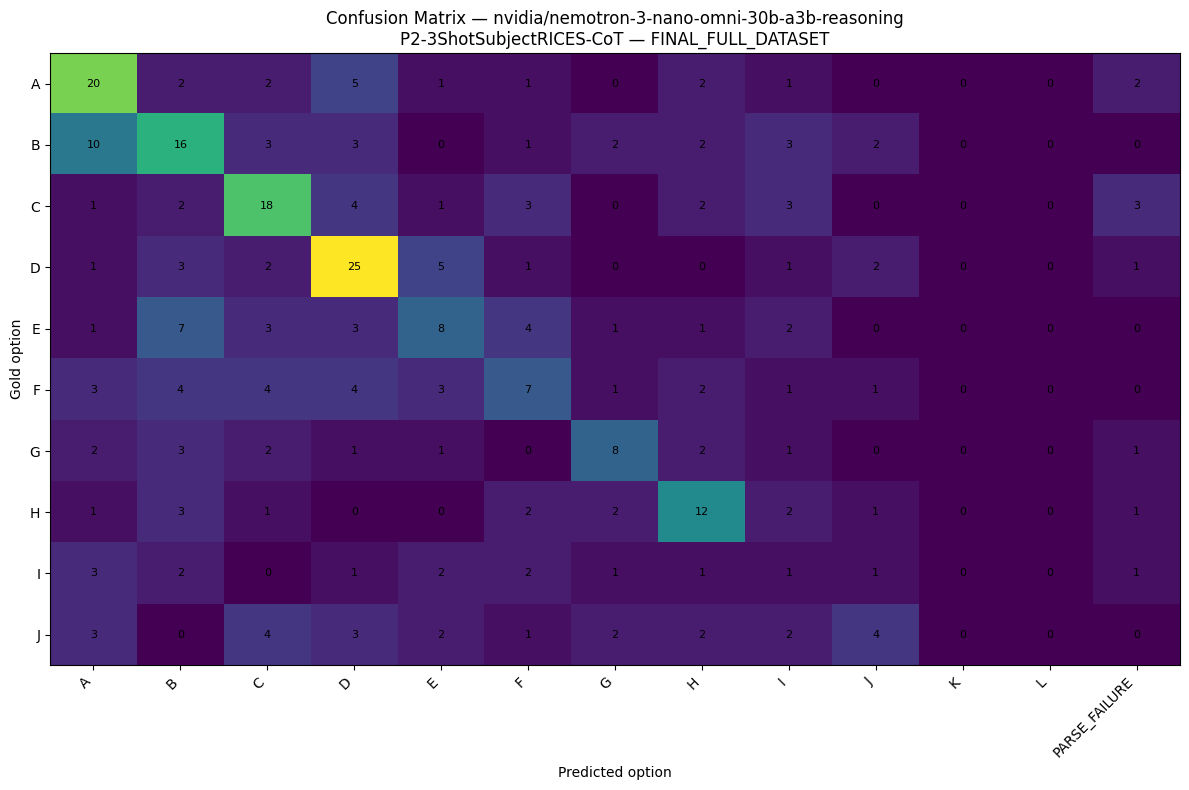

In [20]:
if n_valid:
    observed_labels = choice_letters(int(results["n_options"].max()))
    labels = observed_labels + ["PARSE_FAILURE"]
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    gold_present = [label for label in observed_labels if label in set(y_true)]
    display_matrix = matrix[[labels.index(x) for x in gold_present], :]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(display_matrix, aspect="auto")
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(range(len(gold_present))); ax.set_yticklabels(gold_present)
    ax.set_xlabel("Predicted option"); ax.set_ylabel("Gold option")
    ax.set_title(f"Confusion Matrix — {MODEL}\n{P2_VARIANT_ID} — {status}")
    for i in range(display_matrix.shape[0]):
        for j in range(display_matrix.shape[1]):
            ax.text(j, i, str(display_matrix[i, j]), ha="center", va="center", fontsize=8)
    fig.tight_layout(); fig.savefig(PLOTS_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight"); plt.show()


## 20. Runtime, token, retry, and retrieval statistics


In [21]:
def numeric(series):
    return pd.to_numeric(series, errors="coerce")

sessions = read_jsonl(SESSIONS)
events = read_jsonl(EVENTS)
active_s = sum(float(x.get("session_active_duration_s") or 0) for x in sessions)
efficiency = {}
retrieval_summary = {
    "retrieval_rows": len(retrieval_frame),
    "mean_rank1_total_similarity": float(retrieval_frame[retrieval_frame["rank"] == 1]["total_similarity"].mean()),
    "mean_selected_text_similarity": float(retrieval_frame["text_cosine_similarity"].mean()),
    "mean_selected_image_similarity": float(retrieval_frame["image_cosine_similarity"].mean()),
    "mean_selected_total_similarity": float(retrieval_frame["total_similarity"].mean()),
    "unique_demonstrations_used": int(retrieval_frame["demo_id"].nunique()),
    "query_text_missing_rows": int((~q_text_meta["text_similarity_eligible"].astype(bool)).sum()),
}
display(pd.DataFrame([retrieval_summary]).T.rename(columns={0: "value"}))
if n_valid:
    latency = numeric(results["latency_s"]).dropna()
    prompt_tokens = numeric(results["prompt_tokens"]).dropna()
    completion_tokens = numeric(results["completion_tokens"]).dropna()
    total_tokens = numeric(results["total_tokens"]).dropna()
    attempt_elapsed = [float(x["elapsed_s"]) for x in events if x.get("elapsed_s") is not None and x.get("event") != "retry_backoff"]
    backoffs = [float(x["backoff_s"]) for x in events if x.get("event") == "retry_backoff" and x.get("backoff_s") is not None]
    efficiency = {
        "total_active_kaggle_session_s": active_s,
        "total_active_kaggle_session_h": active_s / 3600,
        "calls_per_min_active_session": 60 * n_valid / active_s if active_s else np.nan,
        "total_successful_api_latency_s": float(latency.sum()),
        "mean_successful_api_latency_s": float(latency.mean()),
        "median_successful_api_latency_s": float(latency.median()),
        "p95_successful_api_latency_s": float(latency.quantile(.95)),
        "total_logged_api_attempt_elapsed_s": float(sum(attempt_elapsed)),
        "total_logged_retry_backoff_s": float(sum(backoffs)),
        "total_prompt_tokens": float(prompt_tokens.sum()) if len(prompt_tokens) else np.nan,
        "mean_prompt_tokens": float(prompt_tokens.mean()) if len(prompt_tokens) else np.nan,
        "total_completion_tokens": float(completion_tokens.sum()) if len(completion_tokens) else np.nan,
        "mean_completion_tokens": float(completion_tokens.mean()) if len(completion_tokens) else np.nan,
        "total_tokens": float(total_tokens.sum()) if len(total_tokens) else np.nan,
        "responses_with_more_than_one_attempt": int((numeric(results["attempts"]) > 1).sum()),
        "logged_retry_events": sum(1 for x in events if x.get("will_retry") is True and x.get("event") != "retry_backoff"),
        "logged_pass_exhaustions": sum(1 for x in events if x.get("event") == "pass_exhausted_without_valid_response"),
        "logged_http_429_events": sum(1 for x in events if x.get("http_status") == 429),
        "strict_parse_failures": int((results["strict_prediction"] == "PARSE_FAILURE").sum()),
        "truncated_responses": int(results["truncated"].astype(bool).sum()),
    }
    display(pd.DataFrame([efficiency]).T.rename(columns={0: "value"}).round(4))


,value
retrieval_rows,900.000000
mean_rank1_total_similarity,1.401038
mean_selected_text_similarity,0.646223
mean_selected_image_similarity,0.702935
mean_selected_total_similarity,1.349158
unique_demonstrations_used,282.000000
query_text_missing_rows,1.000000


,value
total_active_kaggle_session_s,8.606513e+03
total_active_kaggle_session_h,2.390700e+00
calls_per_min_active_session,2.091400e+00
total_successful_api_latency_s,1.944382e+03
mean_successful_api_latency_s,6.481300e+00
median_successful_api_latency_s,4.994000e+00
p95_successful_api_latency_s,1.433390e+01
total_logged_api_attempt_elapsed_s,6.023313e+03
total_logged_retry_backoff_s,1.860000e+03
total_prompt_tokens,1.040902e+06


## 21. Subject, domain, difficulty, image-type, and answer-position analyses


In [22]:
DOMAIN = {
    "Art and Design": ["Art", "Art_Theory", "Design", "Music"],
    "Business": ["Accounting", "Economics", "Finance", "Manage", "Marketing"],
    "Science": ["Biology", "Chemistry", "Geography", "Math", "Physics"],
    "Health and Medicine": ["Basic_Medical_Science", "Clinical_Medicine", "Diagnostics_and_Laboratory_Medicine", "Pharmacy", "Public_Health"],
    "Humanities and Social Science": ["History", "Literature", "Sociology", "Psychology"],
    "Tech and Engineering": ["Agriculture", "Architecture_and_Engineering", "Computer_Science", "Electronics", "Energy_and_Power", "Materials", "Mechanical_Engineering"],
}
subject_to_domain = {subject: domain for domain, subjects in DOMAIN.items() for subject in subjects}


def group_accuracy(frame, column):
    return frame.groupby(column, dropna=False).agg(
        n=("sample_id", "size"), correct=("strict_correct", "sum"),
        accuracy=("strict_correct", "mean"), mean_latency_s=("latency_s", "mean"),
        mean_completion_tokens=("completion_tokens", "mean"),
    ).reset_index()


if n_valid:
    results["domain"] = results["subject"].map(subject_to_domain).fillna("Other/Unmapped")
    subject = group_accuracy(results, "subject")
    domain = group_accuracy(results, "domain")
    difficulty = group_accuracy(results, "topic_difficulty")
    image_type = group_accuracy(results, "img_type")
    image_count = group_accuracy(results, "image_count")
    subject.to_csv(SUBJECT_CSV, index=False); domain.to_csv(DOMAIN_CSV, index=False)
    difficulty.to_csv(DIFF_CSV, index=False); image_type.to_csv(IMGTYPE_CSV, index=False)
    image_count.to_csv(IMGCOUNT_CSV, index=False)
    display(domain.round(4)); display(difficulty.round(4)); display(image_count.round(4)); display(subject.round(4))

    position_labels = choice_letters(int(results["n_options"].max()))
    positions = pd.DataFrame({
        "letter": position_labels,
        "gold_count": results["gold_answer"].value_counts().reindex(position_labels, fill_value=0).values,
        "predicted_count": results["strict_prediction"].value_counts().reindex(position_labels, fill_value=0).values,
    })
    display(positions)


,domain,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Art and Design,40,15,0.3750,6.4831,164.8750
1,Business,50,21,0.4200,5.5899,258.9600
2,Health and Medicine,50,21,0.4200,5.4679,181.6400
3,Humanities and Social Science,40,21,0.5250,5.8550,163.2250
4,Science,50,16,0.3200,4.9614,225.3400
5,Tech and Engineering,70,25,0.3571,9.2842,463.9714


,topic_difficulty,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Easy,88,42,0.4773,5.8790,255.4318
1,Hard,88,23,0.2614,6.8838,283.2386
2,Medium,124,54,0.4355,6.6230,254.0000


,image_count,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,1,278,113,0.4065,6.6811,275.6439
1,2,12,5,0.4167,5.9151,169.3333
2,3,1,0,0.0000,0.8190,5.0000
3,4,5,1,0.2000,1.3864,5.0000
4,5,4,0,0.0000,2.0793,52.0000


,subject,n,correct,accuracy,mean_latency_s,mean_completion_tokens
0,Accounting,10,3,0.3,5.2893,251.2
1,Agriculture,10,5,0.5,9.0877,225.8
2,Architecture_and_Engineering,10,3,0.3,18.4685,883.4
3,Art,10,2,0.2,7.4236,195.9
4,Art_Theory,10,5,0.5,9.7638,215.8
5,Basic_Medical_Science,10,5,0.5,5.6637,201.6
6,Biology,10,3,0.3,4.0895,179.6
7,Chemistry,10,4,0.4,2.5583,100.2
8,Clinical_Medicine,10,3,0.3,7.3211,244.3
9,Computer_Science,10,4,0.4,4.5093,237.7


,letter,gold_count,predicted_count
0,A,36,45
1,B,42,42
2,C,37,39
3,D,41,49
4,E,30,23
5,F,30,22
6,G,21,17
7,H,25,26
8,I,15,17
9,J,23,11


## 22. Qualitative audit viewer


In [23]:
def html_breaks(value):
    return html.escape(str(value or "")).replace("\n", "<br>")


if GENERATE_HTML_AUDIT and n_valid:
    cards = []
    for _, row in results.sort_values("execution_order").iterrows():
        images_html = "".join(
            f'<img src="{html.escape(path)}" style="max-width:420px;max-height:320px;margin:6px;border:1px solid #ddd">'
            for path in str(row["image_files"]).split(";") if path
        )
        options = json.loads(row["options_json"])
        options_html = '<ol type="A">' + "".join(f"<li>{html.escape(str(x))}</li>" for x in options) + "</ol>"
        retrieval_html = html_breaks(json.dumps(json.loads(row["retrieval_json"]), ensure_ascii=False, indent=2))
        verdict = "CORRECT" if bool(row["strict_correct"]) else str(row["error_type"]).upper()
        cards.append(f"""<section style="border:1px solid #bbb;padding:16px;margin:18px 0">
        <h2>{html.escape(str(row['sample_id']))} — {verdict}</h2>
        <p><b>Subject:</b> {html.escape(str(row['subject']))}<br><b>Prediction:</b> {html.escape(str(row['strict_prediction']))}<br><b>Gold:</b> {html.escape(str(row['gold_answer']))}</p>
        <div>{images_html}</div><h3>Question</h3><p>{html_breaks(row['question'])}</p><h3>Options</h3>{options_html}
        <h3>Retrieved demonstrations (ranked)</h3><div style="background:#eef;padding:10px">{retrieval_html}</div>
        <h3>Visible model response</h3><div style="background:#f6f6f6;padding:10px">{html_breaks(row['visible_response'])}</div>
        </section>""")
    document = f'<!doctype html><html><head><meta charset="utf-8"><title>{EXPERIMENT_ID}</title></head><body style="font-family:Arial;max-width:1200px;margin:auto;padding:20px"><h1>{EXPERIMENT_ID}</h1><p><b>Status:</b> {status}; {n_valid}/{n_total}</p>' + "".join(cards) + "</body></html>"
    AUDIT_HTML.write_text(document, encoding="utf-8")
    print("Saved", AUDIT_HTML)


Saved /kaggle/working/nemotron3_nano_omni_p2_3shot_subject_rices_cot_eval300_MAX8192_v1/audit_viewer.html


## 23. Paper-ready summary and completion gate


In [24]:
summary = {
    "analysis_status": status, "experiment_id": EXPERIMENT_ID,
    "experiment_signature": EXPERIMENT_SIGNATURE, "scoring_signature": SCORING_SIGNATURE,
    "model": MODEL, "provider": PROVIDER, "api_method": API_METHOD,
    "dataset_revision": DATASET_REVISION, "n_dataset": n_total, "n_valid": n_valid,
    "coverage": coverage, "prompt_id": PROMPT_ID, "p2_variant_id": P2_VARIANT_ID,
    "prompt_family": PROMPT_FAMILY,
    "prompt_instruction_sha256": PROMPT_INSTRUCTION_SHA256,
    "prompt_template_sha256": PROMPT_TEMPLATE_SHA256,
    "retrieval_map_sha256": RETRIEVAL_MAP_SHA256,
    "image_transport_map_sha256": TRANSPORT_MAP_SHA256,
    "image_transport_policy": IMAGE_TRANSPORT_POLICY,
    "embedding_bundle_signature": EMBEDDING_BUNDLE_SIGNATURE,
    "retrieval": retrieval_summary, "classification": classification,
    "efficiency": efficiency,
    "primary_parser_success": None if pd.isna(fmt) else float(fmt),
    "exact_format_compliance": None if pd.isna(exact_fmt) else float(exact_fmt),
    "truncation_rate": None if pd.isna(trunc) else float(trunc),
    "error_type_counts": {} if error_summary.empty else dict(zip(error_summary["error_type"], error_summary["n"].astype(int))),
}
atomic_json(SUMMARY_JSON, summary)
flat_summary = {
    "analysis_status": status, "model": MODEL, "n_dataset": n_total,
    "n_valid": n_valid, "coverage": coverage, **classification, **efficiency, **retrieval_summary,
}
pd.DataFrame([flat_summary]).to_csv(SUMMARY_CSV, index=False)
display(pd.DataFrame([flat_summary]).T.rename(columns={0: "value"}))


def percent(value):
    return "N/A" if value is None or pd.isna(value) else f"{100*float(value):.2f}%"


readme = f"""# {EXPERIMENT_ID}

## Status
**{status}** — {n_valid}/{n_total} valid provider responses. Only `FINAL_FULL_DATASET` is reportable as the final benchmark result.

## Retrieval
- Prompt condition: `{PROMPT_ID}`
- Collision-safe variant: `{P2_VARIANT_ID}`
- Demonstrations: `{SHOTS}` per query
- Candidate restriction: exact same subject
- Score: `{RETRIEVAL_SCORE}`
- Image aggregation: `{IMAGE_SIMILARITY_AGGREGATION}`
- Tie-break: `{RETRIEVAL_TIEBREAK}`
- Prompt demo order: `{PROMPT_DEMO_ORDER}`
- Retrieval map SHA256: `{RETRIEVAL_MAP_SHA256}`
- Embedding bundle signature: `{EMBEDDING_BUNDLE_SIGNATURE}`
- Embedding model: `{CLIP_REPO}` at `{CLIP_REVISION}`

## Query and demonstration sources
- Query source: `{DATASET_REPO}`, `{DATASET_CONFIG}`, `{DATASET_SPLIT}`, revision `{DATASET_REVISION}`
- Query selected IDs SHA256: `{SELECTED_IDS_CANONICAL_SHA256}`
- Demonstration source: `{DEMO_REPO}`, revision `{DEMO_REVISION}`
- Demonstration CSV SHA256: `{EXPECTED_DEMO_CSV_SHA256}`
- Demonstration ID SHA256: `{EXPECTED_DEMO_IDS_CANONICAL_SHA256}`
- Query/demo overlap: `0`

## Model runtime and generation
- Endpoint: `{MODEL}`
- Provider: `{PROVIDER}`
- API method: `{API_METHOD}`
- SDK: `{SDK_PIN}`
- Temperature: `{TEMPERATURE}`
- Top-p / top-k sent: `False / False`
- Maximum output tokens: `{MAX_TOKENS}`
- Seed: `{API_SEED}`
- Native thinking: disabled through `chat_template_kwargs.enable_thinking=false`
- Provider context ceiling: `{PROVIDER_CONTEXT_TOKENS}` tokens
- Frozen exact-body engineering guard: `{NVIDIA_INLINE_REQUEST_SAFETY_BYTES}` bytes
- Streaming: `{STREAM}`
- Images: `{IMAGE_ORDER_POLICY}`
- Image transport: `{IMAGE_TRANSPORT_POLICY}`
- Image transport map SHA256: `{TRANSPORT_MAP_SHA256}`

## Prompt instruction
```text
{PROMPT_INSTRUCTION}
```

## Headline results
- Strict accuracy: {percent(classification.get('strict_accuracy'))}
- Macro F1: {classification.get('macro_f1', 'N/A')}
- Primary parser success: {percent(fmt)}
- Exact requested-format compliance: {percent(exact_fmt)}
- Truncation rate: {percent(trunc)}

## Resume semantics
HTTP-200 model responses are never content-retried. Timeouts and infrastructure failures remain missing and are retried in the deferred pass or a later exact-signature Kaggle session.

## Canonical artifacts
`run_manifest.json`, `retrieval_map.jsonl`, `retrieval_map.csv`, `image_transport_map.jsonl`, `image_transport_map.csv`, `raw_results.jsonl`, `results_all.csv`, `api_events.jsonl`, `run_sessions.jsonl`, `dataset_manifest.csv`, `demonstration_manifest.csv`, `summary_metrics.json`, `error_type_summary.csv`, and `audit_viewer.html`.
"""
README.write_text(readme, encoding="utf-8")
print(readme)
print("=" * 96)
print("FULL EVAL300 COMPLETE — FINAL_FULL_DATASET" if complete else f"PARTIAL CHECKPOINT — {n_valid}/{n_total}; Save Version, attach output, and rerun.")
print("=" * 96)


,value
analysis_status,FINAL_FULL_DATASET
model,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning
n_dataset,300
n_valid,300
coverage,1.0
strict_accuracy,0.396667
strict_accuracy_wilson_low_95,0.342951
strict_accuracy_wilson_high_95,0.452995
strict_accuracy_bootstrap_low_95,0.34
strict_accuracy_bootstrap_high_95,0.45


# MMMUPro-Eval300__Nemotron3-Nano-Omni-30B-A3B-Reasoning__P2-3ShotSubjectRICES-CoT__NVIDIAHostedAPI__CLIPViTL14__Seed42__MAX8192

## Status
**FINAL_FULL_DATASET** — 300/300 valid provider responses. Only `FINAL_FULL_DATASET` is reportable as the final benchmark result.

## Retrieval
- Prompt condition: `P2`
- Collision-safe variant: `P2-3ShotSubjectRICES-CoT`
- Demonstrations: `3` per query
- Candidate restriction: exact same subject
- Score: `cosine(question_text)+mean_all_pairwise_cosine(physical_images)`
- Image aggregation: `mean over all physical demo/query image embedding pairs`
- Tie-break: `total_score desc; demo_selection_order asc; demo_id asc`
- Prompt demo order: `selected demos in ascending total similarity; nearest immediately before final query`
- Retrieval map SHA256: `0a4fcd36f02a524f97c9b820b804d07649382af1956bc59aa2cfc897df9bbbfe`
- Embedding bundle signature: `22bb7cf10da0bc0806921b81e4144a49dd886c72e42ce07aa0d3c32461589c36`
- Embedding model: `openai/clip-vit-large

## Suggested Methods wording


We evaluated the hosted NVIDIA Nemotron 3 Nano Omni 30B-A3B reasoning-capable model on a frozen, subject-balanced 300-example
subset of the MMMU-Pro Standard-(10-options) test split. The ordered query set
was reconstructed from exact IDs at a pinned dataset revision. A disjoint,
frozen pool of 405 accepted MMMU demonstrations was reconstructed at a second
pinned revision.

Retrieval used separately stored, unit-normalized CLIP ViT-L/14 embeddings of
the question stem and each physical image. Options, labels, explanations, and
generated rationales were excluded from embedding inputs. Candidates were
restricted to the exact query subject and ranked by the sum of question-text
cosine similarity and the mean cosine similarity over all physical query/demo
image pairs. The three highest-scoring demonstrations were inserted from least
to most similar so the closest example immediately preceded the final query.
Each demonstration contained its validated rationale and answer label.

All question and option image markers were resolved at their literal occurrence
positions. Each semantic image label was immediately followed by its image;
repeated references repeated the corresponding image. Every decoded source
image was encoded once as lossless PNG without resizing or a lossy transform.
Images were embedded as exact base64 PNG data URLs in a compact UTF-8 JSON request. All 300 exact serialized request bodies were audited before inference against a frozen 32-MiB engineering guard. The hosted endpoint documented a maximum context length of 256,000 tokens.

Inference used temperature 0, no explicit top-p or top-k, maximum output length
8192, seed 42, disabled provider-native thinking, and non-streaming generation.
Only a declared gold-blind parser of the last non-empty response line
contributed to headline accuracy. Truncated or unparseable outputs counted as
incorrect, no random fallback was used, and successful model responses were
never regenerated because of their content.
